# Model Feature Impact Visualization

901
901
31.0 20.0
(815581, 9) (816801, 9)
(339740, 9) (383669, 9)


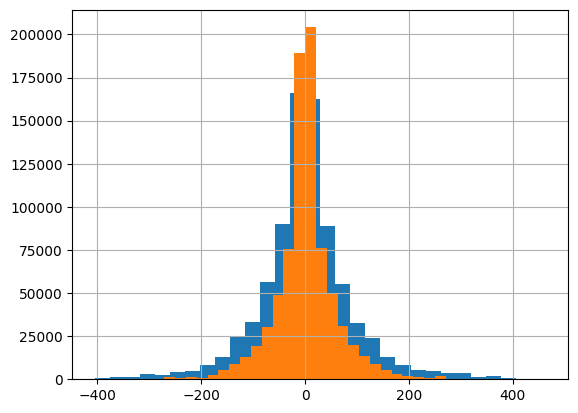

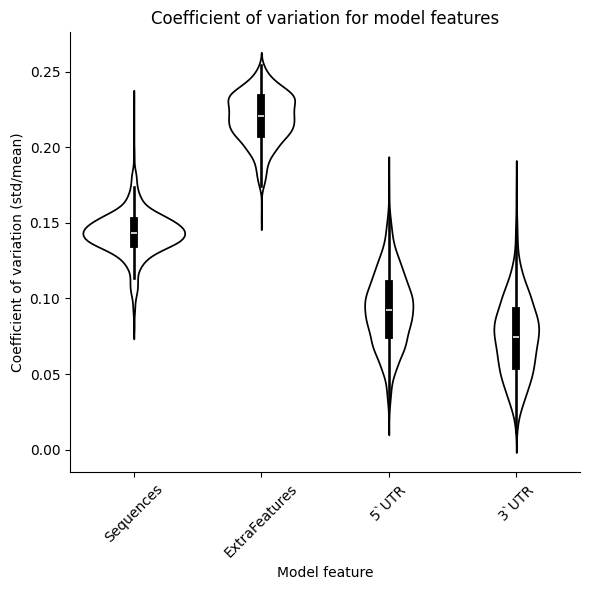

0.14301190632691785 0.2194756653362039 0.09294271138997784 0.0748737415071269


In [1]:
import pandas as pd
import numpy as np
import os
import pickle
from Bio import SeqIO
import matplotlib.pyplot as plt
import seaborn as sns

try:
    seqImpact = pd.read_csv('output/data/sanityCheck/seqImpact_predictions.csv',engine='pyarrow',dtype_backend='pyarrow') # checks the impact of the sequences on predictions (extraFeatures the extraFeatImpact for all sequences)
except:
    os.chdir('../..')
    os.getcwd()
    seqImpact = pd.read_csv('output/data/sanityCheck/seqImpact_predictions.csv',engine='pyarrow',dtype_backend='pyarrow') # checks the impact of the sequences on predictions (extraFeatures the extraFeatImpact for all sequences)

extraFeatImpact = pd.read_csv('output/data/sanityCheck/extraFeatImpact_predictions.csv',engine='pyarrow',dtype_backend='pyarrow') # checks the impact of the extraFeatures on predictions (sequence the extraFeatImpact for all extraFeatures)
utr5Impact = pd.read_csv('output/data/sanityCheck/5UTRImpact_predictions.csv',engine='pyarrow',dtype_backend='pyarrow') 
utr3Impact = pd.read_csv('output/data/sanityCheck/3UTRImpact_predictions.csv',engine='pyarrow',dtype_backend='pyarrow') 

eGroups = [f'{a}_{o}' for a,o in zip(extraFeatImpact['actual'],extraFeatImpact['originalPrediction'])]
eGroups_fixed = []
prevGroup = None
counts = {}
for i, group in enumerate(eGroups):
    if group != prevGroup:
        if group not in counts:
            counts[group] = 0
        else:
            counts[group] += 1
    eGroups_fixed.append(group+f'_{counts[group]}')
    prevGroup = group

print(len(seqImpact['trID'].unique()))
print(len(set(eGroups_fixed)))

from Bio import SeqIO
import os
from transformers import AutoTokenizer
import pandas as pd

try:
    seqs = SeqIO.to_dict(SeqIO.parse('output/data/decay/dev.fasta', 'fasta'))
except:
    os.chdir('../..')
    seqs = SeqIO.to_dict(SeqIO.parse('output/data/decay/dev.fasta', 'fasta'))
    
tokenizer = AutoTokenizer.from_pretrained('output/ftModel/best_spearmanr')
utr3Lengths = {v.description.split()[1]:len(tokenizer.encode(str(v.seq.split(',')[1].replace('U','T')),add_special_tokens=False)) for k,v in seqs.items()}
utr5Lengths = {v.description.split()[1]:len(tokenizer.encode(str(v.seq.split(',')[0].replace('U','T')),add_special_tokens=False)) for k,v in seqs.items()}

# Convert utr3Lengths and utr5Lengths dictionaries to lists of lengths
utr3_lengths = list(utr3Lengths.values())
utr5_lengths = list(utr5Lengths.values())

utr3Impact_copy = utr3Impact.copy()
utr3Impact_copy['utr3Length'] = utr3Impact_copy['pertID'].map(utr3Lengths)
utr3Impact_copy['utr3LengthOriginal'] = utr3Impact_copy['trID'].map(utr3Lengths)
utr3Impact_copy['lenDiff'] = utr3Impact_copy['utr3Length'] - utr3Impact_copy['utr3LengthOriginal']
utr3Impact_copy['lenDiff'].hist(bins=30)

#utr3Impact_copy = utr3Impact_copy[utr3Impact_copy['lenDiff'] < 20]
utr5Impact_copy = utr5Impact.copy()
utr5Impact_copy['utr5Length'] = utr5Impact_copy['pertID'].map(utr5Lengths)
utr5Impact_copy['utr5LengthOriginal'] = utr5Impact_copy['trID'].map(utr5Lengths)
utr5Impact_copy['lenDiff'] = utr5Impact_copy['utr5Length'] - utr5Impact_copy['utr5LengthOriginal']
utr5Impact_copy['lenDiff'].hist(bins=30)

filt3 = np.ceil(np.std(utr3Impact_copy['lenDiff'])/3)
filt5 = np.ceil(np.std(utr5Impact_copy['lenDiff'])/3)
print(filt3, filt5)
print(utr3Impact_copy.shape, utr5Impact_copy.shape)
utr3Impact_copy = utr3Impact_copy[np.abs(utr3Impact_copy['lenDiff']) < filt3]
utr5Impact_copy = utr5Impact_copy[np.abs(utr5Impact_copy['lenDiff']) < filt5]
print(utr3Impact_copy.shape, utr5Impact_copy.shape)


sImp = seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).std()/ seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).mean()
eImp = extraFeatImpact['perturbedPrediction'].groupby(eGroups_fixed).std()/ extraFeatImpact['perturbedPrediction'].groupby(eGroups_fixed).mean()
u5Imp = utr5Impact_copy['perturbedPrediction'].groupby(utr5Impact_copy['trID']).std()/ utr5Impact_copy['perturbedPrediction'].groupby(utr5Impact_copy['trID']).mean()
u3Imp = utr3Impact_copy['perturbedPrediction'].groupby(utr3Impact_copy['trID']).std()/ utr3Impact_copy['perturbedPrediction'].groupby(utr3Impact_copy['trID']).mean()
# Create dataframe for plotting
plot_data_imp = pd.DataFrame({
    'Impact': list(sImp) + list(eImp) + list(u5Imp) + list(u3Imp),
    'Feature': ['Sequences'] * len(sImp) + 
               ['ExtraFeatures'] * len(eImp) + 
               ['5`UTR'] * len(u5Imp) + 
               ['3`UTR'] * len(u3Imp)
})

# Create violin plot
plt.figure(figsize=(6, 6))
sns.violinplot(data=plot_data_imp, x='Feature', y='Impact', color='white', edgecolor='black')
plt.title('Coefficient of variation for model features')
plt.ylabel('Coefficient of variation (std/mean)')
plt.xlabel('Model feature')
plt.xticks(rotation=45)
plt.tight_layout()
# Remove top and right spines to show only x and y axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('figures/model_feature_impact_violin_plot.svg')
plt.show()

print(np.mean(sImp), np.mean(eImp), np.mean(u5Imp), np.mean(u3Imp))

# Linear model with motif counts

Number of unique RBPs: 51
Created dictionary with 4243 entries
First few entries:
FBtr0081843: 0.34404852416958664
FBtr0084166: 0.7308060935938796
FBtr0100446: 0.7849753945728306
FBtr0078857: 0.610145827906886
FBtr0083574: 0.9239241641828473
Coefficients with p-values:
                   RBP  Coefficient  Std_Error  T_Statistic   P_Value
56   3' UTR GC Content    -0.259483   0.062844    -4.129021  0.000037
93                 CAT    -2.795230   0.773536    -3.613575  0.000306
54   5' UTR GC Content    -0.197523   0.054794    -3.604841  0.000316
58                 TTC    -2.509953   0.699414    -3.588650  0.000336
73                 TCT    -2.623559   0.901816    -2.909196  0.003643
..                 ...          ...        ...          ...       ...
68                 ATG    -0.097296   0.679215    -0.143248  0.886101
27            ORB2_rbp    -0.000536   0.003796    -0.141210  0.887711
9          CG33714_rbp     0.000400   0.003250     0.122933  0.902166
36            REF2_rbp     0.0

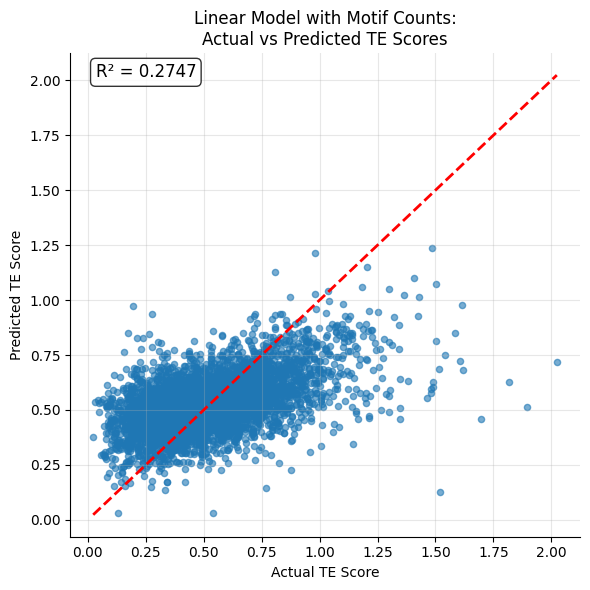

In [39]:
from Bio import SeqIO
import pandas as pd
import os

# Read the file, skipping the first two lines that start with #
df = pd.read_csv('output/mast_out/train_mast_results.txt', sep='\s+', skiprows=2, skipfooter=1, engine='python')
df.columns = ['sequence_name', 'strand', 'id', 'alt_id', 'hit_start','hit_end','score','p_value']

# Count unique RBPs in alt_id column
unique_rbps = df['alt_id'].nunique()
print(f"Number of unique RBPs: {unique_rbps}")

# Create new column 'trID' by splitting sequence_name on '_' and taking index 0
df['trID'] = df['sequence_name'].str.split('_').str[0]

# Count alt_ids for each unique trID value
alt_id_counts_per_trID = df.groupby(['trID','alt_id']).count().reset_index().iloc[:,:3]
alt_id_counts_per_trID.columns = ['trID', 'alt_id_count', 'counts']

# Pivot the dataframe to have trID as rows and alt_id_count as columns with counts as values
alt_id_counts_per_trID_pivoted = alt_id_counts_per_trID.pivot(index='trID', columns='alt_id_count', values='counts').fillna(0).astype(int)
alt_id_counts_per_trID_pivoted.columns = alt_id_counts_per_trID_pivoted.columns+'_rbp'

# Create dictionary to map trID to TE_value
te_dict = {}

# Read the fasta file and extract trID and TE_value from description
with open('output/data/decay/train.fasta', 'r') as fasta_file:
    for seq_record in SeqIO.parse(fasta_file, 'fasta'):
        description_parts = seq_record.description.split()
        te_value = description_parts[0]
        tr_id = description_parts[1]
        te_dict[tr_id] = te_value

print(f"Created dictionary with {len(te_dict)} entries")
print("First few entries:")
for i, (key, value) in enumerate(te_dict.items()):
    if i < 5:
        print(f"{key}: {value}")
    else:
        break

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from scipy import stats

# Create a dataframe with TE values for the trIDs in the pivoted dataframe
te_df = pd.DataFrame.from_dict(te_dict, orient='index', columns=['TE_value'])
te_df.index.name = 'trID'

# Convert TE_value to numeric
te_df['TE_value'] = pd.to_numeric(te_df['TE_value'])

# Merge the pivoted dataframe with TE values
merged_df = alt_id_counts_per_trID_pivoted.merge(te_df, left_index=True, right_index=True, how='inner')

# Read the additional feature files
extra_features = pd.read_csv('output/data/codons/extraFeatures.csv',index_col=0).drop(['Residuals','Decay Rate'], axis=1)
vienna_features = pd.read_csv('output/data/codons/vienna_features.csv',index_col=0)[['mfe']]

# Merge the additional features with the existing merged_df
merged_df = merged_df.merge(extra_features, left_index=True, right_index=True, how='left')
merged_df = merged_df.merge(vienna_features, left_index=True, right_index=True, how='left')
merged_df.dropna(inplace=True)

# Prepare features (X) and target (y)
X = merged_df.drop('TE_value', axis=1)
y = merged_df['TE_value']

# Create and fit the linear regression model using all data
model = LinearRegression()
model.fit(X, y)

# Make predictions on the same data
y_pred = model.predict(X)

# Calculate p-values for coefficients
n = X.shape[0]  # number of observations
p = X.shape[1]  # number of features
dof = n - p - 1  # degrees of freedom

# Calculate residuals and mean squared error
residuals = y - y_pred
mse = np.sum(residuals**2) / dof

# Calculate standard errors
X_with_intercept = np.column_stack([np.ones(n), X])
cov_matrix = mse * np.linalg.inv(X_with_intercept.T @ X_with_intercept)
std_errors = np.sqrt(np.diag(cov_matrix)[1:])  # exclude intercept

# Calculate t-statistics and p-values
t_stats = model.coef_ / std_errors
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))

# Create results dataframe
results_df = pd.DataFrame({
    'RBP': X.columns,
    'Coefficient': model.coef_,
    'Std_Error': std_errors,
    'T_Statistic': t_stats,
    'P_Value': p_values
}).sort_values('P_Value')

print("Coefficients with p-values:")
print(results_df)

RBPrank = []
RBPdirection = []
# Sort results_df by T_Statistic from high to low
results_df_sorted = results_df.sort_values('T_Statistic', ascending=False)

for index, row in results_df_sorted.iterrows():
    if '_rbp' in row['RBP']:
        RBPrank.append(row['RBP'].split('_')[0])
        RBPdirection.append(1 if row['Coefficient'] > 0 else -1)

RBPrank

import matplotlib.pyplot as plt

# Create scatter plot of actual vs predicted TE scores
plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.6, s=20)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual TE Score')
plt.ylabel('Predicted TE Score')
plt.title('Linear Model with Motif Counts:\nActual vs Predicted TE Scores')
#plt.legend()
plt.grid(True, alpha=0.3)

# Add R² score to the plot
plt.text(0.05, 0.95, f'R² = {r2_score(y, y_pred):.4f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
# Remove top and right spines to show only x and y axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('figures/linearModel_motifCounts_actual_vs_predicted_TE_scores.svg')
plt.show()

In [40]:
results_df_sorted[results_df_sorted['RBP'].str.contains('_rbp')]

,RBP,Coefficient,Std_Error,T_Statistic,P_Value
2,B52_rbp,0.006290,0.003583,1.755804,0.079196
17,FMR1_rbp,0.006130,0.003742,1.638017,0.101494
42,SF2_rbp,0.006010,0.004451,1.350236,0.177015
4,CG11360_rbp,0.004353,0.004020,1.082789,0.278966
38,RNP4F_rbp,0.003622,0.003561,1.017236,0.309101
40,RSF1_rbp,0.003012,0.003665,0.821668,0.411313
11,CG7804_rbp,0.003312,0.004122,0.803542,0.421708
13,CNOT4_rbp,0.002138,0.002765,0.773391,0.439335
19,HOW_rbp,0.002359,0.003257,0.724278,0.468936
47,SRP54_rbp,0.003640,0.005062,0.719058,0.472146


# Compare simple high vs low model to LLM model and the motif strengths from the linear model with motif counts

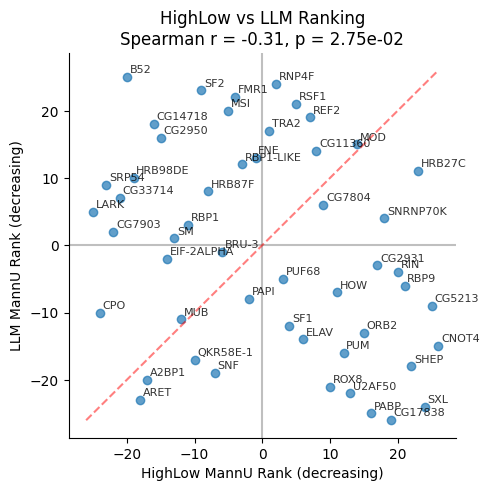

Spearman correlation: -0.31
P-value: 2.75e-02
Number of common motifs: 51


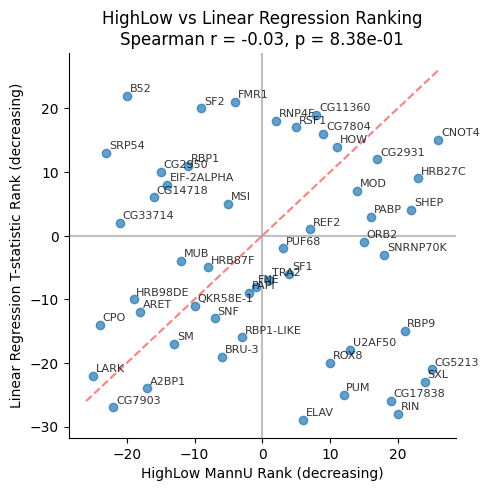

HighLow vs Linear Regression:
Spearman correlation: -0.03, p-value: 8.38e-01
Number of common motifs: 51


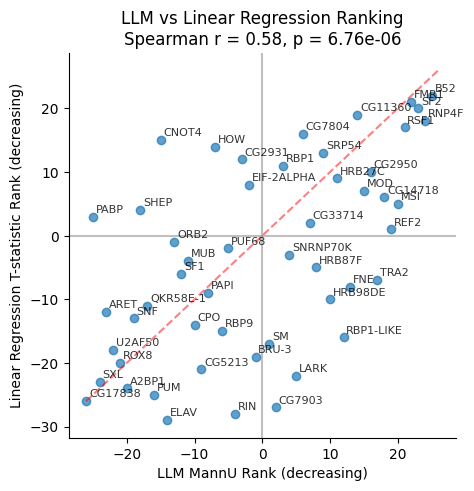


LLM vs Linear Regression:
Spearman correlation: 0.58, p-value: 6.76e-06
Number of common motifs: 51


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

try:
    llm = pd.read_csv(f'output/motifEnrichment/train_pos5_mannwhitneyu_results.csv',index_col=0)
except:
    import os
    os.chdir('../..')
    os.getcwd()
    llm = pd.read_csv(f'output/motifEnrichment/train_pos5_mannwhitneyu_results.csv',index_col=0)
highLow = pd.read_csv(f'output/motifEnrichment/train_utr5_mannwhitneyu_results.csv',index_col=0)

# Create rank columns for both dataframes
highLow_ranked = highLow.copy()
highLow_ranked['negLog10_p_value'] = -np.log10(highLow_ranked['p_value'])
highLow_ranked['direction'] = np.where(highLow_ranked['motif_mean'] > highLow_ranked['control_mean'], 1, -1)
highLow_ranked['rank_num'] = highLow_ranked['negLog10_p_value'] * highLow_ranked['direction']
highLow_ranked.sort_values('rank_num', ascending=False, inplace=True)

# Assign ranks: positive for positive direction, negative for negative direction
positive_mask = highLow_ranked['direction'] == 1
negative_mask = highLow_ranked['direction'] == -1
num_positive = positive_mask.sum()
num_negative = negative_mask.sum()
highLow_ranked.loc[positive_mask, 'rank_num'] = range(num_positive, 0, -1)
highLow_ranked.loc[negative_mask, 'rank_num'] = range(-1, -num_negative - 1, -1)

llm_ranked = llm.copy()
llm_ranked['negLog10_p_value'] = -np.log10(llm_ranked['p_value'])
llm_ranked['direction'] = np.where(llm_ranked['motif_mean'] > llm_ranked['control_mean'], 1, -1)
llm_ranked['rank_num'] = llm_ranked['negLog10_p_value'] * llm_ranked['direction']
llm_ranked.sort_values('rank_num', ascending=False, inplace=True)
llm_ranked['rank_num'] = range(len(llm_ranked), 0, -1)

# Assign ranks: positive for positive direction, negative for negative direction
positive_mask = llm_ranked['direction'] == 1
negative_mask = llm_ranked['direction'] == -1
num_positive = positive_mask.sum()
num_negative = negative_mask.sum()
llm_ranked.loc[positive_mask, 'rank_num'] = range(num_positive, 0, -1)
llm_ranked.loc[negative_mask, 'rank_num'] = range(-1, -num_negative - 1, -1)

# Merge on motif_alt_ID to get common motifs
merged = pd.merge(highLow_ranked[['rank_num']], 
                  llm_ranked[['rank_num']], 
                  left_index=True, right_index=True,
                  suffixes=('_highLow', '_llm'))

from scipy.stats import spearmanr

# Calculate Spearman correlation
corr, p_value = spearmanr(merged['rank_num_highLow'], merged['rank_num_llm'])


### HighVLow vs LLM Motif Ranking Comparison

# Create scatter plot
plt.figure(figsize=(5, 5))
plt.scatter(merged['rank_num_highLow'], merged['rank_num_llm'], alpha=0.7)
# Add grey grid lines at y=0 and x=0
plt.axhline(y=0, color='grey', linestyle='-', alpha=0.5)
plt.axvline(x=0, color='grey', linestyle='-', alpha=0.5)

# Add motif_alt_ID labels to each point
for i, row in merged.iterrows():
    plt.annotate(i, 
                (row['rank_num_highLow'], row['rank_num_llm']),
                xytext=(2,3), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.xlabel('HighLow MannU Rank (decreasing)')
plt.ylabel('LLM MannU Rank (decreasing)')
plt.title(f'HighLow vs LLM Ranking\nSpearman r = {corr:.2f}, p = {p_value:.2e}')

# Add diagonal line for reference
max_rank = max(merged['rank_num_highLow'].max(), merged['rank_num_llm'].max())
min_rank = min(merged['rank_num_highLow'].min(), merged['rank_num_llm'].min())
plt.plot([min_rank, max_rank], [min_rank, max_rank], 'r--', alpha=0.5, label='Perfect correlation')


# Remove top and right spines to show only x and y axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('figures/motif_rank_comparison_highLow_vs_llm.svg')
plt.show()

# Print correlation results
print(f"Spearman correlation: {corr:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"Number of common motifs: {len(merged)}")

### HighVLow vs linear model and LLM vs linear model Motif Ranking Comparison

# Create dataframes with linear regression ranks
linearRegressionRank_df = pd.DataFrame({
    'rank_num': range(len(RBPrank), 0, -1),
    'direction': RBPdirection
}, index=RBPrank)

# Assign ranks: positive for positive direction, negative for negative direction
positive_mask = linearRegressionRank_df['direction'] == 1
negative_mask = linearRegressionRank_df['direction'] == -1
num_positive = positive_mask.sum()
num_negative = negative_mask.sum()
linearRegressionRank_df.loc[positive_mask, 'rank_num'] = range(num_positive, 0, -1)
linearRegressionRank_df.loc[negative_mask, 'rank_num'] = range(-1, -num_negative - 1, -1)

# Merge highLow with linear regression ranks
merged_highLow_lr = pd.merge(highLow_ranked[['rank_num']], 
                            linearRegressionRank_df[['rank_num']], 
                            left_index=True, right_index=True,
                            suffixes=('_highLow', '_lr'))

# Merge llm with linear regression ranks
merged_llm_lr = pd.merge(llm_ranked[['rank_num']], 
                        linearRegressionRank_df[['rank_num']], 
                        left_index=True, right_index=True,
                        suffixes=('_llm', '_lr'))


# Calculate Spearman correlations
corr_highLow_lr, p_val_highLow_lr = spearmanr(merged_highLow_lr['rank_num_highLow'], 
                                              merged_highLow_lr['rank_num_lr'])
corr_llm_lr, p_val_llm_lr = spearmanr(merged_llm_lr['rank_num_llm'], 
                                      merged_llm_lr['rank_num_lr'])

# Plot HighLow vs Linear Regression
plt.figure(figsize=(5, 5))
plt.scatter(merged_highLow_lr['rank_num_highLow'], merged_highLow_lr['rank_num_lr'], alpha=0.7)
# Add grey grid lines at y=0 and x=0
plt.axhline(y=0, color='grey', linestyle='-', alpha=0.5)
plt.axvline(x=0, color='grey', linestyle='-', alpha=0.5)

for i, row in merged_highLow_lr.iterrows():
    plt.annotate(i, 
                (row['rank_num_highLow'], row['rank_num_lr']),
                xytext=(2,3), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.xlabel('HighLow MannU Rank (decreasing)')
plt.ylabel('Linear Regression T-statistic Rank (decreasing)')
plt.title(f'HighLow vs Linear Regression Ranking\nSpearman r = {corr_highLow_lr:.2f}, p = {p_val_highLow_lr:.2e}')

# Add diagonal line for reference
max_rank = max(merged['rank_num_highLow'].max(), merged['rank_num_llm'].max())
min_rank = min(merged['rank_num_highLow'].min(), merged['rank_num_llm'].min())
plt.plot([min_rank, max_rank], [min_rank, max_rank], 'r--', alpha=0.5, label='Perfect correlation')

#plt.legend()
#plt.grid(True, alpha=0.3)
# Remove top and right spines to show only x and y axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('figures/motif_rank_comparison_highLow_vs_linear_regression.svg')
plt.show()

print(f"HighLow vs Linear Regression:")
print(f"Spearman correlation: {corr_highLow_lr:.2f}, p-value: {p_val_highLow_lr:.2e}")
print(f"Number of common motifs: {len(merged_highLow_lr)}")

# Plot LLM vs Linear Regression
plt.figure(figsize=(5, 5))
plt.scatter(merged_llm_lr['rank_num_llm'], merged_llm_lr['rank_num_lr'], alpha=0.7)
# Add grey grid lines at y=0 and x=0
plt.axhline(y=0, color='grey', linestyle='-', alpha=0.5)
plt.axvline(x=0, color='grey', linestyle='-', alpha=0.5)

for i, row in merged_llm_lr.iterrows():
    plt.annotate(i, 
                (row['rank_num_llm'], row['rank_num_lr']),
                xytext=(2,3), textcoords='offset points',
                fontsize=8, alpha=0.8)

plt.xlabel('LLM MannU Rank (decreasing)')
plt.ylabel('Linear Regression T-statistic Rank (decreasing)')
plt.title(f'LLM vs Linear Regression Ranking\nSpearman r = {corr_llm_lr:.2f}, p = {p_val_llm_lr:.2e}')

# Add diagonal line for reference
max_rank = max(merged['rank_num_highLow'].max(), merged['rank_num_llm'].max())
min_rank = min(merged['rank_num_highLow'].min(), merged['rank_num_llm'].min())
plt.plot([min_rank, max_rank], [min_rank, max_rank], 'r--', alpha=0.5, label='Perfect correlation')

#plt.legend()
#plt.grid(True, alpha=0.3)
# Remove top and right spines to show only x and y axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('figures/motif_rank_comparison_llm_vs_linear_regression.svg')
plt.show()

print(f"\nLLM vs Linear Regression:")
print(f"Spearman correlation: {corr_llm_lr:.2f}, p-value: {p_val_llm_lr:.2e}")
print(f"Number of common motifs: {len(merged_llm_lr)}")


# Motif Enrichment results LLM

100%|██████████| 51/51 [00:00<00:00, 10117.27it/s]


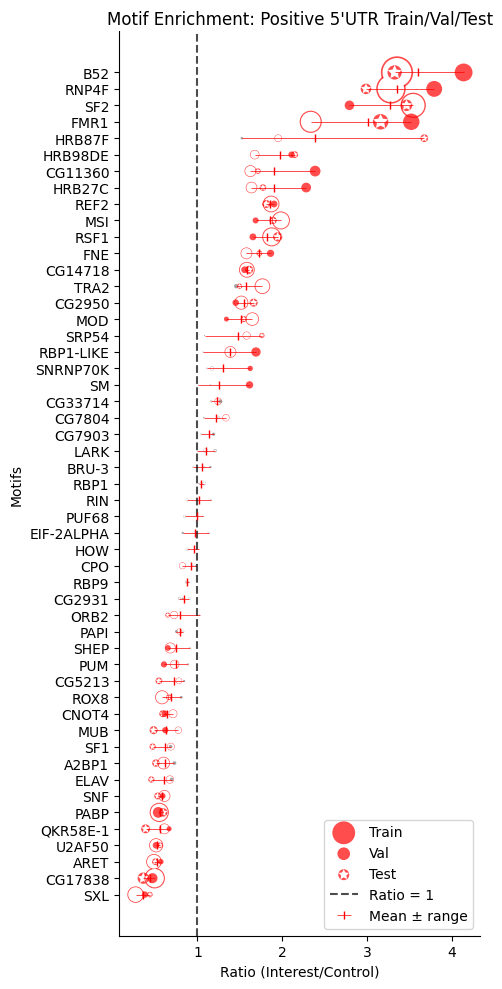

100%|██████████| 51/51 [00:00<00:00, 9090.93it/s]


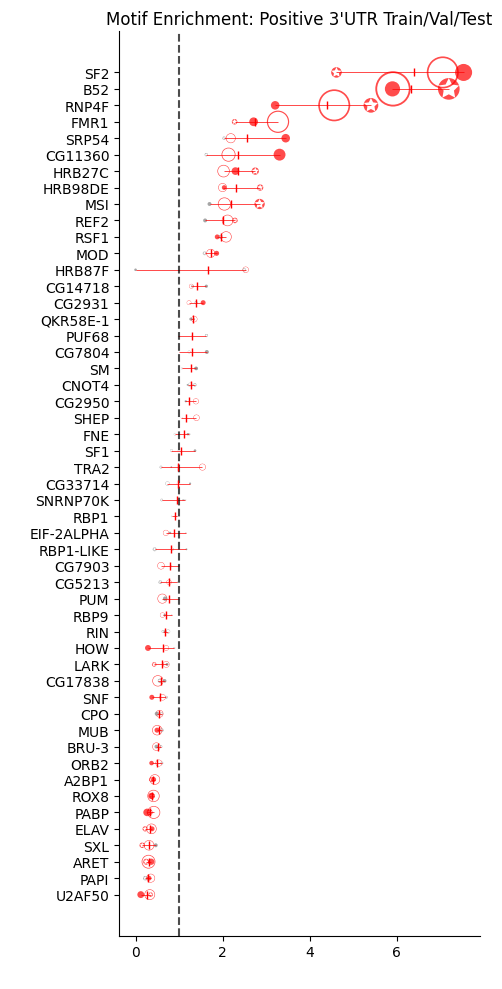

100%|██████████| 51/51 [00:00<00:00, 8681.04it/s]


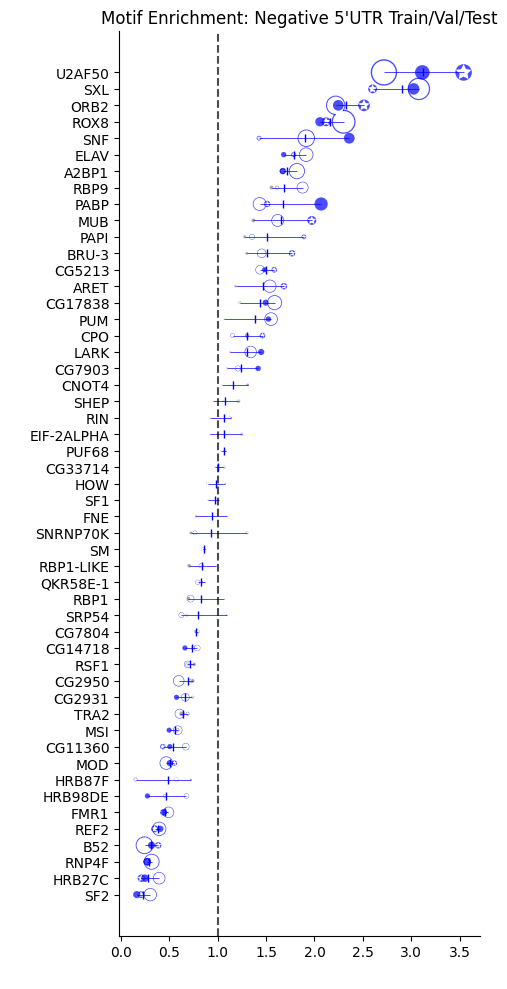

100%|██████████| 51/51 [00:00<00:00, 9486.85it/s]


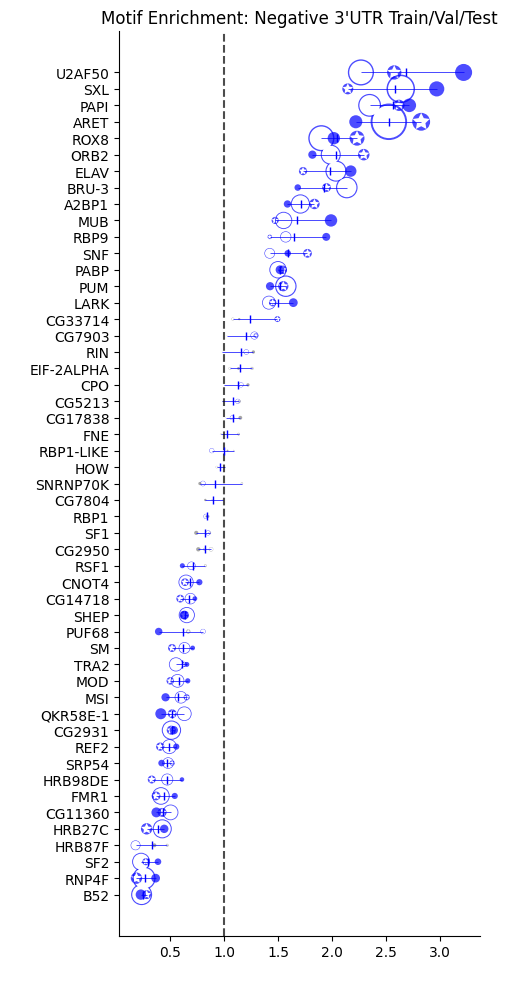

In [24]:
from adjustText import adjust_text

import numpy as np
import pandas as pd
from adjustText import adjust_text
import tqdm

import matplotlib.patches as mpath
star = mpath.Path.unit_regular_star(5)
circle = mpath.Path.unit_circle()
# concatenate the circle with an internal cutout of the star
cut_star = mpath.Path(
    vertices=np.concatenate([circle.vertices, star.vertices[::-1, ...]]),
    codes=np.concatenate([circle.codes, star.codes]))
import matplotlib.pyplot as plt
# Read the files and filter out rows starting with '#'
try:
    trainPos5 = pd.read_csv(f'output/motifEnrichment/train_pos5_mannwhitneyu_results.csv',index_col=0)
except:
    import os
    os.chdir('../..')
    os.getcwd()
    trainPos5 = pd.read_csv(f'output/motifEnrichment/train_pos5_mannwhitneyu_results.csv',index_col=0)
trainPos3 = pd.read_csv(f'output/motifEnrichment/train_pos3_mannwhitneyu_results.csv',index_col=0)
trainNeg5 = pd.read_csv(f'output/motifEnrichment/train_neg5_mannwhitneyu_results.csv',index_col=0)
trainNeg3 = pd.read_csv(f'output/motifEnrichment/train_neg3_mannwhitneyu_results.csv',index_col=0)

devPos5 = pd.read_csv(f'output/motifEnrichment/dev_pos5_mannwhitneyu_results.csv',index_col=0)
devPos3 = pd.read_csv(f'output/motifEnrichment/dev_pos3_mannwhitneyu_results.csv',index_col=0)  
devNeg5 = pd.read_csv(f'output/motifEnrichment/dev_neg5_mannwhitneyu_results.csv',index_col=0)
devNeg3 = pd.read_csv(f'output/motifEnrichment/dev_neg3_mannwhitneyu_results.csv',index_col=0)

testPos5 = pd.read_csv(f'output/motifEnrichment/test_pos5_mannwhitneyu_results.csv',index_col=0)
testPos3 = pd.read_csv(f'output/motifEnrichment/test_pos3_mannwhitneyu_results.csv',index_col=0)
testNeg5 = pd.read_csv(f'output/motifEnrichment/test_neg5_mannwhitneyu_results.csv',index_col=0)
testNeg3 = pd.read_csv(f'output/motifEnrichment/test_neg3_mannwhitneyu_results.csv',index_col=0)

Threshold = 0.05
count = 0
interestRBPs = {}
for train, dev, test, direction in zip([trainPos5, trainPos3, trainNeg5, trainNeg3], 
                             [devPos5, devPos3, devNeg5, devNeg3], 
                             [testPos5, testPos3, testNeg5, testNeg3],
                             ["Positive 5'UTR", "Positive 3'UTR", "Negative 5'UTR", "Negative 3'UTR"]):
    # Create crosshair plot
    plt.figure(figsize=(5, 10))

    myColor = '#ff0000ff' if direction.startswith("Positive") else '#0000ffff'

    texts = []
    motif_list = []
    ratio_mean = []
    ratio_min = []
    ratio_max = []
    ratio_train = []
    ratio_dev = []
    ratio_test = []
    ratio_min = []
    neg_log_mean = []
    neg_log_train = []
    neg_log_dev = []
    neg_log_test = []
    interestRBPs[direction] = []
    for motif_id in tqdm.tqdm(trainPos5.index.tolist()):
        # Get values for this motif from all three datasets
        p_adj = [train.loc[motif_id, 'p_adj'], 
                    dev.loc[motif_id, 'p_adj'], 
                    test.loc[motif_id, 'p_adj']]
        ratio = [train.loc[motif_id, 'motif_mean']/train.loc[motif_id, 'control_mean'],
                    dev.loc[motif_id, 'motif_mean']/dev.loc[motif_id, 'control_mean'], 
                    test.loc[motif_id, 'motif_mean']/test.loc[motif_id, 'control_mean']]
        if p_adj[0] < Threshold and ratio[0] > 1:
            if all(r > 1 for r in ratio):
                interestRBPs[direction].append(motif_id)
            else:
                print(f"Warning: {motif_id} is significant in train {direction} but not consistently enriched across datasets.")

        # Calculate -log10 p-values
        neg_log_p = [-np.log10(p) for p in p_adj]

        # Calculate means for the center point
        mean_neg_log_p = np.mean(neg_log_p)
        mean_ratio = np.mean(ratio)
        #if mean_ratio < 1:
        #    continue

        # Collect data for plotting
        motif_list.append(motif_id)
        ratio_mean.append(mean_ratio)
        ratio_min.append(mean_ratio - min(ratio))
        ratio_max.append(max(ratio) - mean_ratio)
        ratio_train.append(ratio[0])
        ratio_dev.append(ratio[1])
        ratio_test.append(ratio[2])
        neg_log_mean.append(mean_neg_log_p)
        neg_log_train.append(neg_log_p[0])
        neg_log_dev.append(neg_log_p[1])
        neg_log_test.append(neg_log_p[2])

        ## Add motif labels for significant ones (will adjust after loop)
        #if mean_neg_log_p >= -np.log10(Threshold):
        #    # Placeholder for text, will create after loop with correct y positions
        #    pass

    # After the loop, create the plot
    y_positions = list(range(len(motif_list)))
    # reorder the lists based on ratio_mean
    sorted_indices = np.argsort(ratio_mean)
    motif_list = [motif_list[i] for i in sorted_indices]
    ratio_mean = [ratio_mean[i] for i in sorted_indices]
    ratio_min = [ratio_min[i] for i in sorted_indices]
    ratio_max = [ratio_max[i] for i in sorted_indices]
    ratio_train = [ratio_train[i] for i in sorted_indices]
    ratio_dev = [ratio_dev[i] for i in sorted_indices]
    ratio_test = [ratio_test[i] for i in sorted_indices]
    neg_log_mean = [neg_log_mean[i] for i in sorted_indices]
    neg_log_train = [neg_log_train[i] for i in sorted_indices]
    neg_log_dev = [neg_log_dev[i] for i in sorted_indices]
    neg_log_test = [neg_log_test[i] for i in sorted_indices]
    sizeModifier = 8
    sizes_train = [p * sizeModifier for p in neg_log_train]  # Scale size by neg_log_p, adjust multiplier as needed
    sizes_dev = [p * sizeModifier for p in neg_log_dev]  # Scale size by neg_log_p, adjust multiplier as needed
    sizes_test = [p * sizeModifier for p in neg_log_test]  # Scale size by neg_log_p, adjust multiplier as needed
    colors_train = ['grey' if nl <= -np.log10(Threshold) else myColor for nl in neg_log_train]
    colors_dev = ['grey' if nl <= -np.log10(Threshold) else myColor for nl in neg_log_dev]
    colors_test = ['grey' if nl <= -np.log10(Threshold) else myColor for nl in neg_log_test]
    plt.errorbar(ratio_mean, y_positions, xerr=[ratio_min, ratio_max], fmt='|', color=myColor, ecolor=myColor, elinewidth=0.5, capsize=0, label='Mean ± range')
    plt.scatter(ratio_train, y_positions, s=sizes_train, c=colors_train, edgecolors='none', marker='o', alpha=0.7, label='Train')
    plt.scatter(ratio_train, y_positions, s=[x*0.8 for x in sizes_train], c='white', edgecolors='none', marker='o', )
    #plt.scatter(ratio_mean, y_positions, c=myColor, marker='|', alpha=0.7, label='Mean')
    plt.scatter(ratio_dev, y_positions, s=sizes_dev, c=colors_dev, edgecolors='none', marker='o', alpha=0.7, label='Val')
    plt.scatter(ratio_test, y_positions, s=sizes_test, c=colors_test, edgecolors='none', marker=cut_star, alpha=0.7, label='Test')
    plt.yticks(y_positions, motif_list)
    
    # # Add annotations for significant motifs
    # texts = []
    # for i, motif in enumerate(motif_list):
    # if neg_log_mean[i] >= -np.log10(Threshold):
    #     text = plt.annotate(motif, (ratio_list[i], y_positions[i]), fontsize=8, alpha=0.7)
    #     texts.append(text)
    
    # # Apply adjustText after the loop
    # if texts:
    # adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

    myC = 'black' if count == 0 else 'white'
    plt.xlabel('Ratio (Interest/Control)',color=myC)
    plt.ylabel('Motifs',color=myC)
    plt.title(f'Motif Enrichment: {direction} Train/Val/Test')

    # Add vertical line at ratio = 1
    plt.axvline(x=1, color='black', linestyle='--', alpha=0.7, label='Ratio = 1')

    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if count == 0:
        plt.legend()
    plt.tight_layout()
    plt.savefig(f'figures/{direction}_dot_plot_motif_enrichment.svg')
    plt.show()
    count += 1

myInterestRBPs = interestRBPs.copy()

In [5]:
import itertools

# Define the sets
sets = {
    "Positive 5'UTR": set(interestRBPs["Positive 5'UTR"]),
    "Positive 3'UTR": set(interestRBPs["Positive 3'UTR"]),
    "Negative 5'UTR": set(interestRBPs["Negative 5'UTR"]),
    "Negative 3'UTR": set(interestRBPs["Negative 3'UTR"])
}

# Compute and print exclusive intersections for a 4-way Venn diagram
for r in range(1, 5):
    for combo in itertools.combinations(sets.keys(), r):
        inter = set.intersection(*(sets[k] for k in combo))
        other_sets = [sets[k] for k in sets if k not in combo]
        union_others = set.union(*other_sets) if other_sets else set()
        exclusive = inter - union_others
        combo_str = " & ".join(combo)
        print(f"{combo_str} ({len(exclusive)} RBPs, {len(inter)} total): {sorted(exclusive)} ")

# Calculate the total number of unique RBPs across all four groups
total_unique = set.union(*(sets.values()))
print(f"Total unique RBPs across all groups: {len(total_unique)}")

Positive 5'UTR (6 RBPs, 20 total): ['CG33714', 'CG7804', 'FNE', 'HRB87F', 'RBP1-LIKE', 'TRA2'] 
Positive 3'UTR (3 RBPs, 17 total): ['CG2931', 'QKR58E-1', 'SHEP'] 
Negative 5'UTR (2 RBPs, 19 total): ['CG5213', 'CPO'] 
Negative 3'UTR (0 RBPs, 17 total): [] 
Positive 5'UTR & Positive 3'UTR (14 RBPs, 14 total): ['B52', 'CG11360', 'CG14718', 'CG2950', 'FMR1', 'HRB27C', 'HRB98DE', 'MOD', 'MSI', 'REF2', 'RNP4F', 'RSF1', 'SF2', 'SRP54'] 
Positive 5'UTR & Negative 5'UTR (0 RBPs, 0 total): [] 
Positive 5'UTR & Negative 3'UTR (0 RBPs, 0 total): [] 
Positive 3'UTR & Negative 5'UTR (0 RBPs, 0 total): [] 
Positive 3'UTR & Negative 3'UTR (0 RBPs, 0 total): [] 
Negative 5'UTR & Negative 3'UTR (17 RBPs, 17 total): ['A2BP1', 'ARET', 'BRU-3', 'CG17838', 'CG7903', 'ELAV', 'LARK', 'MUB', 'ORB2', 'PABP', 'PAPI', 'PUM', 'RBP9', 'ROX8', 'SNF', 'SXL', 'U2AF50'] 
Positive 5'UTR & Positive 3'UTR & Negative 5'UTR (0 RBPs, 0 total): [] 
Positive 5'UTR & Positive 3'UTR & Negative 3'UTR (0 RBPs, 0 total): [] 
Positi

100%|██████████| 51/51 [00:00<00:00, 10274.73it/s]

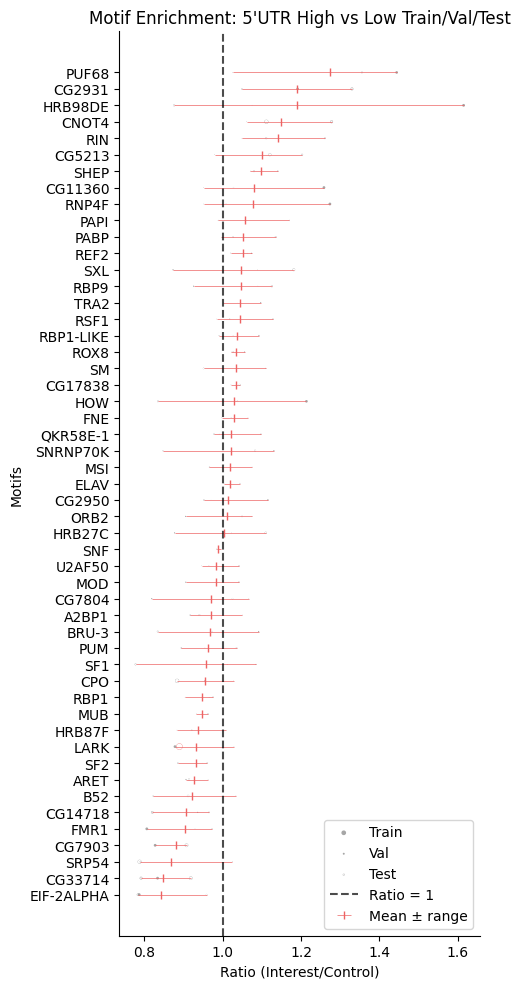

100%|██████████| 51/51 [00:00<00:00, 8948.69it/s]


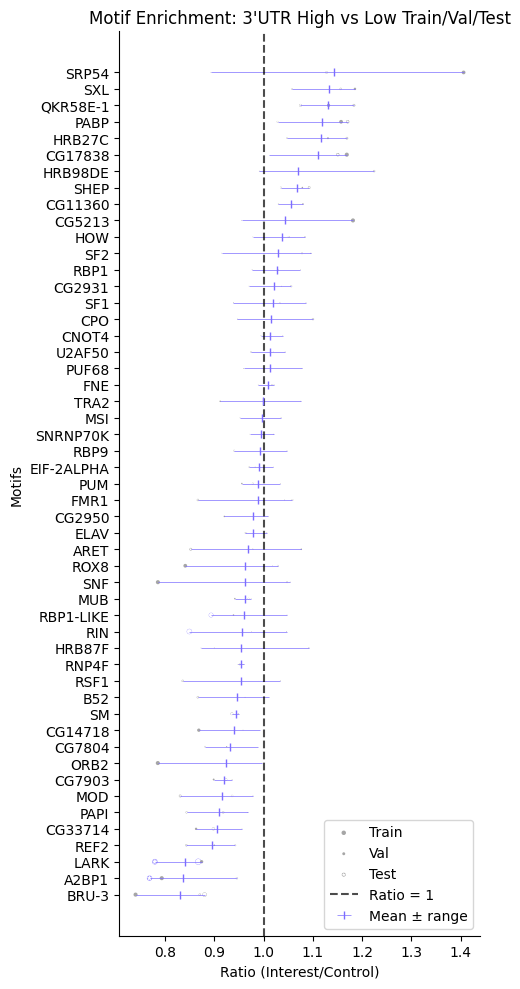

In [21]:
from adjustText import adjust_text

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from adjustText import adjust_text
import tqdm

# Read the files and filter out rows starting with '#'
try:
    trainPos5 = pd.read_csv(f'output/motifEnrichment/train_utr5_mannwhitneyu_results.csv',index_col=0)
except:
    import os
    os.chdir('../..')
    os.getcwd()
    trainPos5 = pd.read_csv(f'output/motifEnrichment/train_utr5_mannwhitneyu_results.csv',index_col=0)
trainPos3 = pd.read_csv(f'output/motifEnrichment/train_utr3_mannwhitneyu_results.csv',index_col=0)

devPos5 = pd.read_csv(f'output/motifEnrichment/dev_utr5_mannwhitneyu_results.csv',index_col=0)
devPos3 = pd.read_csv(f'output/motifEnrichment/dev_utr3_mannwhitneyu_results.csv',index_col=0)  

testPos5 = pd.read_csv(f'output/motifEnrichment/test_utr5_mannwhitneyu_results.csv',index_col=0)
testPos3 = pd.read_csv(f'output/motifEnrichment/test_utr3_mannwhitneyu_results.csv',index_col=0)

Threshold = 0.05
interestRBPs = {}
for train, dev, test, direction in zip([trainPos5, trainPos3], 
                             [devPos5, devPos3], 
                             [testPos5, testPos3],
                             ["5'UTR High vs Low", "3'UTR High vs Low"]):
    # Create crosshair plot
    plt.figure(figsize=(5, 10))

    myColor = '#ed6363ff' if direction.startswith("5") else '#7c6dffff'

    texts = []
    motif_list = []
    ratio_mean = []
    ratio_min = []
    ratio_max = []
    ratio_train = []
    ratio_dev = []
    ratio_test = []
    ratio_min = []
    neg_log_mean = []
    neg_log_train = []
    neg_log_dev = []
    neg_log_test = []
    interestRBPs[direction] = []
    for motif_id in tqdm.tqdm(trainPos5.index.tolist()):
        # Get values for this motif from all three datasets
        p_adj = [train.loc[motif_id, 'p_adj'], 
                    dev.loc[motif_id, 'p_adj'], 
                    test.loc[motif_id, 'p_adj']]
        ratio = [train.loc[motif_id, 'motif_mean']/train.loc[motif_id, 'control_mean'],
                    dev.loc[motif_id, 'motif_mean']/dev.loc[motif_id, 'control_mean'], 
                    test.loc[motif_id, 'motif_mean']/test.loc[motif_id, 'control_mean']]
        if p_adj[0] < Threshold and ratio[0] > 1:
            if all(r > 1 for r in ratio):
                interestRBPs[direction].append(motif_id)
            else:
                print(f"Warning: {motif_id} is significant in train {direction} but not consistently enriched across datasets.")

        # Calculate -log10 p-values
        neg_log_p = [-np.log10(p) for p in p_adj]

        # Calculate means for the center point
        mean_neg_log_p = np.mean(neg_log_p)
        mean_ratio = np.mean(ratio)
        #if mean_ratio < 1:
        #    continue

        # Collect data for plotting
        motif_list.append(motif_id)
        ratio_mean.append(mean_ratio)
        ratio_min.append(mean_ratio - min(ratio))
        ratio_max.append(max(ratio) - mean_ratio)
        ratio_train.append(ratio[0])
        ratio_dev.append(ratio[1])
        ratio_test.append(ratio[2])
        neg_log_mean.append(mean_neg_log_p)
        neg_log_train.append(neg_log_p[0])
        neg_log_dev.append(neg_log_p[1])
        neg_log_test.append(neg_log_p[2])

        ## Add motif labels for significant ones (will adjust after loop)
        #if mean_neg_log_p >= -np.log10(Threshold):
        #    # Placeholder for text, will create after loop with correct y positions
        #    pass

    # After the loop, create the plot
    y_positions = list(range(len(motif_list)))
    # reorder the lists based on ratio_mean
    sorted_indices = np.argsort(ratio_mean)
    motif_list = [motif_list[i] for i in sorted_indices]
    ratio_mean = [ratio_mean[i] for i in sorted_indices]
    ratio_min = [ratio_min[i] for i in sorted_indices]
    ratio_max = [ratio_max[i] for i in sorted_indices]
    ratio_train = [ratio_train[i] for i in sorted_indices]
    ratio_dev = [ratio_dev[i] for i in sorted_indices]
    ratio_test = [ratio_test[i] for i in sorted_indices]
    neg_log_mean = [neg_log_mean[i] for i in sorted_indices]
    neg_log_train = [neg_log_train[i] for i in sorted_indices]
    neg_log_dev = [neg_log_dev[i] for i in sorted_indices]
    neg_log_test = [neg_log_test[i] for i in sorted_indices]
    sizeModifier = 8
    sizes_train = [p * sizeModifier for p in neg_log_train]  # Scale size by neg_log_p, adjust multiplier as needed
    sizes_dev = [p * sizeModifier for p in neg_log_dev]  # Scale size by neg_log_p, adjust multiplier as needed
    sizes_test = [p * sizeModifier for p in neg_log_test]  # Scale size by neg_log_p, adjust multiplier as needed
    colors_train = ['grey' if nl <= -np.log10(Threshold) else myColor for nl in neg_log_train]
    colors_dev = ['grey' if nl <= -np.log10(Threshold) else myColor for nl in neg_log_dev]
    colors_test = ['grey' if nl <= -np.log10(Threshold) else myColor for nl in neg_log_test]
    plt.errorbar(ratio_mean, y_positions, xerr=[ratio_min, ratio_max], fmt='|', color=myColor, ecolor=myColor, elinewidth=0.5, capsize=0, label='Mean ± range')
    plt.scatter(ratio_train, y_positions, s=sizes_train, c=colors_train, edgecolors='none', marker='o', alpha=0.7, label='Train')
    plt.scatter(ratio_train, y_positions, s=[x*0.8 for x in sizes_train], c='white', edgecolors='none', marker='o', )
    #plt.scatter(ratio_mean, y_positions, c=myColor, marker='|', alpha=0.7, label='Mean')
    plt.scatter(ratio_dev, y_positions, s=sizes_dev, c=colors_dev, edgecolors='none', marker='o', alpha=0.7, label='Val')
    plt.scatter(ratio_test, y_positions, s=sizes_test, c=colors_test, edgecolors='none', marker=cut_star, alpha=0.7, label='Test')
    plt.yticks(y_positions, motif_list)
    
    # # Add annotations for significant motifs
    # texts = []
    # for i, motif in enumerate(motif_list):
    # if neg_log_mean[i] >= -np.log10(Threshold):
    #     text = plt.annotate(motif, (ratio_list[i], y_positions[i]), fontsize=8, alpha=0.7)
    #     texts.append(text)
    
    # # Apply adjustText after the loop
    # if texts:
    # adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

    plt.xlabel('Ratio (Interest/Control)')
    plt.ylabel('Motifs')
    plt.title(f'Motif Enrichment: {direction} Train/Val/Test')

    # Add vertical line at ratio = 1
    plt.axvline(x=1, color='black', linestyle='--', alpha=0.7, label='Ratio = 1')

    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.legend()
    plt.tight_layout()
    plt.savefig(f'figures/{direction}_dot_plot_motif_enrichment.svg')
    plt.show()

In [7]:
import itertools

# Define the sets
# Define the sets
sets = {
    "5'UTR High vs Low": set(interestRBPs["5'UTR High vs Low"]),
    "3'UTR High vs Low": set(interestRBPs["3'UTR High vs Low"])
}

# Compute and print exclusive intersections for a 4-way Venn diagram
for r in range(1, len(sets)+1):
    for combo in itertools.combinations(sets.keys(), r):
        inter = set.intersection(*(sets[k] for k in combo))
        other_sets = [sets[k] for k in sets if k not in combo]
        union_others = set.union(*other_sets) if other_sets else set()
        exclusive = inter - union_others
        combo_str = " & ".join(combo)
        print(f"{combo_str} ({len(exclusive)} RBPs, {len(inter)} total): {sorted(exclusive)} ")

# Calculate the total number of unique RBPs across all four groups
total_unique = set.union(*(sets.values()))
print(f"Total unique RBPs across all groups: {len(total_unique)}")


5'UTR High vs Low (0 RBPs, 0 total): [] 
3'UTR High vs Low (0 RBPs, 0 total): [] 
5'UTR High vs Low & 3'UTR High vs Low (0 RBPs, 0 total): [] 
Total unique RBPs across all groups: 0


# SHAP to AME

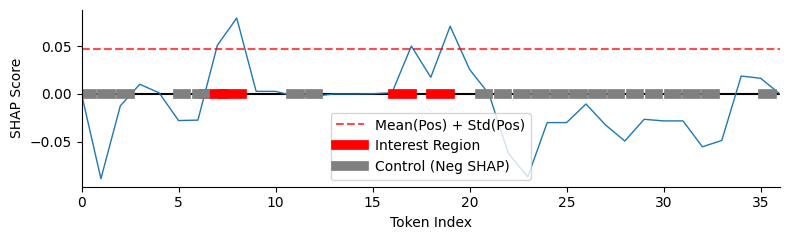

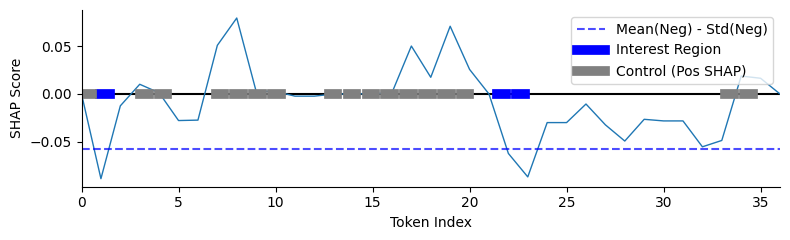

-0.005358218559337221
-0.008334905702770472
-0.0033071947577882066
-0.005693026055883033
-0.006990424076843698


In [8]:
import pickle
import os
import numpy as np
from matplotlib import pyplot as plt

try:
    os.chdir('scripts')
    from myShap import Explainer
    from myShap.ferret_extras import BaseExplainer, Explanation
    os.chdir('..')
    with open("output/importance/dev_shap.pkl", "rb") as f:
        importances = pickle.load(f)
except:
    os.chdir('../../scripts')
    print(os.getcwd())
    from myShap import Explainer
    from myShap.ferret_extras import BaseExplainer, Explanation
    os.chdir('..')
    print(os.getcwd())
    with open("output/importance/dev_shap.pkl", "rb") as f:
        importances = pickle.load(f)


imp = None
scores = []
preds = []
for i in importances:
    if i.id == 'FBtr0084901':#'FBtr0076276':#'FBtr0475046':
        imp = i
    scores.append(i.scores.flatten().tolist())
    preds.append(i.prediction)

score = imp.scores.flatten().tolist()
score
tmpMean = np.mean([x for x in score if x > 0])
tmpStd = np.std([x for x in score if x > 0])
negMean = np.mean([x for x in score if x < 0])
negStd = np.std([x for x in score if x < 0])

plt.figure(figsize=(8, 2.5))
plt.axhline(y=0, color='black', linestyle='-')
plt.plot(range(len(score)), score, linewidth=1)
plt.axhline(y=tmpMean+tmpStd, color='red', linestyle='--', alpha=0.7, label=f'Mean(Pos) + Std(Pos)')
plt.xlim(left=0, right=len(score)-1)

# Add horizontal red lines at y=0 for positions where score > tmpMean+tmpStd
threshold = tmpMean + tmpStd
count = 0
for i, s in enumerate(score):
    if s > threshold:
        # Convert data coordinates to normalized coordinates
        xmin_norm = max(0, (i-0.5) / len(score))
        xmax_norm = min(1, (i+0.5) / len(score))
        plt.axhline(y=0, xmin=xmin_norm, xmax=xmax_norm, color='red', linewidth=7, label = 'Interest Region' if count == 0 else "")
        count += 1

# Add horizontal red lines at y=0 for positions where score > tmpMean+tmpStd
threshold = 0
count = 0
for i, s in enumerate(score):
    if s <= threshold:
        # Convert data coordinates to normalized coordinates
        xmin_norm = max(0, (i+0.1) / len(score))
        xmax_norm = min(1, (i+0.55) / len(score))
        plt.axhline(y=0, xmin=xmin_norm, xmax=xmax_norm, color='grey', linewidth=7,label='Control (Neg SHAP)' if count == 0 else "")
        count += 1

plt.xlabel('Token Index')
plt.ylabel('SHAP Score')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.legend()
plt.savefig('figures/AME_thresholds_pos.svg')
plt.show()

plt.figure(figsize=(8, 2.5))
plt.axhline(y=0, color='black', linestyle='-')
plt.plot(range(len(score)), score, linewidth=1)
plt.axhline(y=negMean-negStd, color='blue', linestyle='--', alpha=0.7, label=f'Mean(Neg) - Std(Neg)')
plt.xlim(left=0, right=len(score)-1)

# Add horizontal red lines at y=0 for positions where score > tmpMean+tmpStd
threshold = negMean - negStd
count = 0
for i, s in enumerate(score):
    if s < threshold:
        # Convert data coordinates to normalized coordinates
        xmin_norm = max(0, (i) / len(score))
        xmax_norm = min(1, (i+0.5) / len(score))
        plt.axhline(y=0, xmin=xmin_norm, xmax=xmax_norm, color='blue', linewidth=7, label='Interest Region' if count == 0 else "")
        count += 1

# Add horizontal red lines at y=0 for positions where score > tmpMean+tmpStd
threshold = 0
count = 0
for i, s in enumerate(score):
    if s >= threshold:
        # Convert data coordinates to normalized coordinates
        xmin_norm = max(0, (i+0.1) / len(score))
        xmax_norm = min(1, (i+0.55) / len(score))
        plt.axhline(y=0, xmin=xmin_norm, xmax=xmax_norm, color='grey', linewidth=7, label='Control (Pos SHAP)' if i == 0 else "")
        count += 1

plt.xlabel('Token Index')
plt.ylabel('SHAP Score')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.legend()
plt.savefig('figures/AME_thresholds_neg.svg')
plt.show()

print(np.mean([item for sublist in scores for item in sublist]))
print(np.mean([np.mean(sublist) for sublist in scores]))
print(np.median([item for sublist in scores for item in sublist]))
print(np.median([np.median(sublist) for sublist in scores]))
print(np.median([np.mean(sublist) for sublist in scores]))

# ablations val and spearman scatter plot

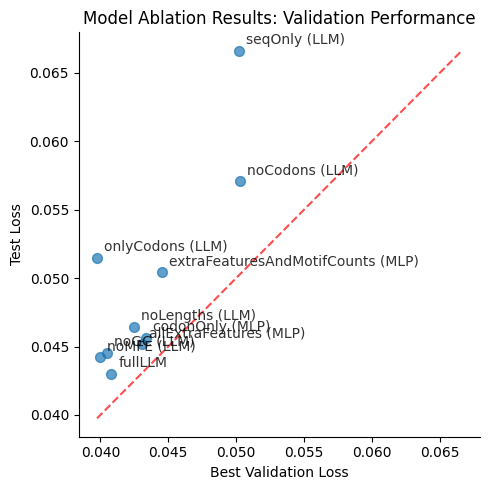

,model,train_mse,val_mse,test_mse
0,fullLLM,0.039323,0.040817,0.043008
0,seqOnly (LLM),0.059640,0.050206,0.066627
0,onlyCodons (LLM),0.045631,0.039756,0.051465
0,noCodons (LLM),0.062704,0.050262,0.057079
0,noMFE (LLM),0.039868,0.040003,0.044226
0,noLengths (LLM),0.043476,0.042449,0.046434
0,noGC (LLM),0.035233,0.040490,0.044536
0,allExtraFeatures (MLP),0.051047,0.043078,0.045177
0,codonOnly (MLP),0.056360,0.043396,0.045658
0,extraFeaturesAndMotifCounts (MLP),0.054611,0.044521,0.050420


In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt

try:
    seq_only = pd.read_csv('output/ray_ablations/seq_only/ray_tune_results.csv')
except:
    import os
    os.chdir('../..')
    seq_only = pd.read_csv('output/ray_ablations/seq_only/ray_tune_results.csv')


data = pd.DataFrame()
tmp_train = pd.read_csv(f'dvclive/TE/plots/metrics/train/loss.tsv',header=0,sep='\t')
tmp_val = pd.read_csv(f'dvclive/TE/plots/metrics/val/loss.tsv',header=0,sep='\t')
tmp_test = json.load(open(f'output/predict/test_results.json'))
tmp = pd.DataFrame({'model': 'fullLLM', 'train_mse': [tmp_train['loss'][tmp_val['loss'].idxmin()]],'val_mse': [tmp_val['loss'].min()], 'test_mse': [tmp_test['eval_loss']]})
data = pd.concat([data, tmp], axis=0)
labels = {'seq_only': 'seqOnly (LLM)', 'only_codons': 'onlyCodons (LLM)', 'no_codons': 'noCodons (LLM)', 'no_mfe': 'noMFE (LLM)', 'no_lengths': 'noLengths (LLM)','no_gc_content': 'noGC (LLM)'}
for a in ['seq_only','only_codons','no_codons','no_mfe','no_lengths','no_gc_content']:
    try:# output/predict_seq_only/test_results.txt
        tmp_train = pd.read_csv(f'dvclive/TE/{a}/plots/metrics/train/loss.tsv',header=0,sep='\t')
        tmp_val = pd.read_csv(f'dvclive/TE/{a}/plots/metrics/val/loss.tsv',header=0,sep='\t')
        tmp_test = json.load(open(f'output/predict_{a}/test_results.json'))
        tmp = pd.DataFrame({'model': labels[a],'val_mse': [tmp_val['loss'].min()], 'test_mse': [tmp_test['eval_loss']], 'train_mse': [tmp_train['loss'][tmp_val['loss'].idxmin()]]})
        data = pd.concat([data, tmp], axis=0)
    except:
        print(f"File for {a} not found, skipping...")

for a in ['allExtraFeatures','codonOnly','extraFeaturesAndMotifCounts']:
    try:# dvclive/codonOnlyClassificationMLP/allExtraFeatures_final/metrics.json
        tmp_train = pd.read_csv(f'dvclive/codonOnlyClassificationMLP/{a}_final/plots/metrics/train/loss.tsv',header=0,sep='\t')
        tmp_val = pd.read_csv(f'dvclive/codonOnlyClassificationMLP/{a}_final/plots/metrics/val/loss.tsv',header=0,sep='\t')
        tmp_test = json.load(open(f'dvclive/codonOnlyClassificationMLP/{a}_final/metrics.json'))
        tmp = pd.DataFrame({'model': [a+' (MLP)'],'val_mse': [tmp_val['loss'].min()], 'test_mse': [tmp_test['test']['loss']], 'train_mse': [tmp_train['loss'][tmp_val['loss'].idxmin()]]})
        data = pd.concat([data, tmp], axis=0)
    except:
        print(f"File for {a} not found, skipping...")

plt.figure(figsize=(5, 5))
plt.scatter(data['val_mse'], data['test_mse'], alpha=0.7, s=50)

# Add model labels to each point
for i, row in data.iterrows():
    plt.annotate(row['model'], 
                (row['val_mse'], row['test_mse']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, alpha=0.8)

# Add diagonal line for reference
min_val = min(data['val_mse'].min(), data['test_mse'].min())
max_val = max(data['val_mse'].max(), data['test_mse'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='x=y')

plt.ylabel('Test Loss')
plt.xlabel('Best Validation Loss')
plt.title('Model Ablation Results: Validation Performance')
#plt.grid(True, alpha=0.3)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('figures/model_ablation_results_scatter.svg')
plt.show()

data

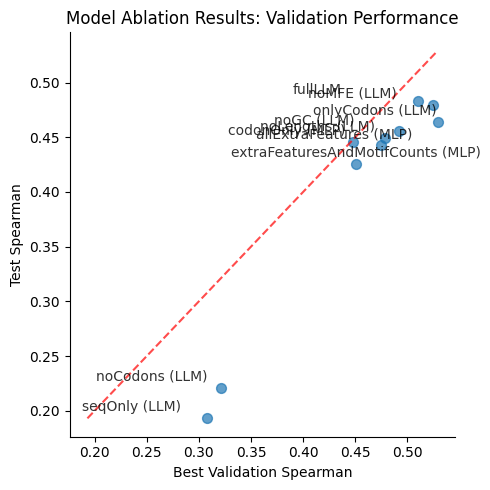

In [6]:
import pandas as pd
import json
import matplotlib.pyplot as plt

try:
    seq_only = pd.read_csv('output/ray_ablations/seq_only/ray_tune_results.csv')
except:
    import os
    os.chdir('../..')
    seq_only = pd.read_csv('output/ray_ablations/seq_only/ray_tune_results.csv')


data = pd.DataFrame()
tmp_val = json.load(open(f'dvclive/TE/metrics.json'))
tmp_test = json.load(open(f'output/predict/test_results.json'))
tmp = pd.DataFrame({'model': 'fullLLM','val_spearmanr': [tmp_val['global']['best_spearmanr']], 'test_spearmanr': [tmp_test['spearmanr']]})
data = pd.concat([data, tmp], axis=0)
labels = {'seq_only': 'seqOnly (LLM)', 'only_codons': 'onlyCodons (LLM)', 'no_codons': 'noCodons (LLM)', 'no_mfe': 'noMFE (LLM)', 'no_lengths': 'noLengths (LLM)','no_gc_content': 'noGC (LLM)'}
for a in ['seq_only','only_codons','no_codons','no_mfe','no_lengths','no_gc_content']:
    try:# output/predict_seq_only/test_results.txt
        tmp_val = json.load(open(f'dvclive/TE/{a}/metrics.json'))
        tmp_test = json.load(open(f'output/predict_{a}/test_results.json'))
        tmp = pd.DataFrame({'model': labels[a],'val_spearmanr': [tmp_val['global']['best_spearmanr']], 'test_spearmanr': [tmp_test['spearmanr']]})
        data = pd.concat([data, tmp], axis=0)
    except:
        print(f"File for {a} not found, skipping...")

for a in ['allExtraFeatures','codonOnly','extraFeaturesAndMotifCounts']:
    try:# dvclive/codonOnlyClassificationMLP/allExtraFeatures_final/metrics.json
        tmp_spearman = json.load(open(f'dvclive/codonOnlyClassificationMLP/{a}_final/metrics.json'))
        tmp = pd.DataFrame({'model': [a+' (MLP)'],'val_spearmanr': [tmp_spearman['global']['best_spearmanr']], 'test_spearmanr': [tmp_spearman['test']['spearmanr']]})
        data = pd.concat([data, tmp], axis=0)
    except:
        print(f"File for {a} not found, skipping...")

plt.figure(figsize=(5, 5))
plt.scatter(data['val_spearmanr'], data['test_spearmanr'], alpha=0.7, s=50)

# Add model labels to each point
for i, row in data.iterrows():
    plt.annotate(row['model'], 
                (row['val_spearmanr'], row['test_spearmanr']),
                xytext=(-90, 5), textcoords='offset points',
                fontsize=10, alpha=0.8)

# Add diagonal line for reference
min_val = min(data['val_spearmanr'].min(), data['test_spearmanr'].min())
max_val = max(data['val_spearmanr'].max(), data['test_spearmanr'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='x=y')

plt.ylabel('Test Spearman')
plt.xlabel('Best Validation Spearman')
plt.title('Model Ablation Results: Validation Performance')
#plt.grid(True, alpha=0.3)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/model_ablation_results_scatter_spearman.svg')
plt.show()

Full LLM, seq only, codon only, correlation between seq only and codon only

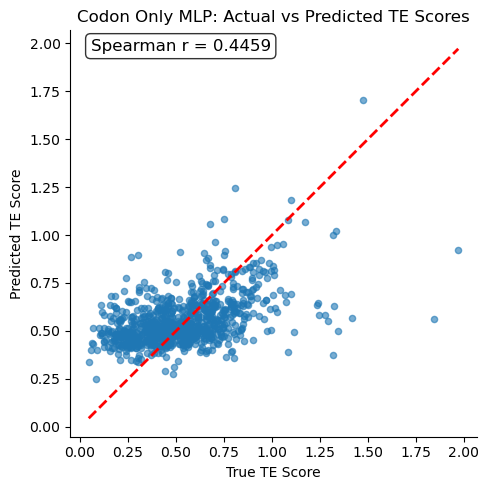

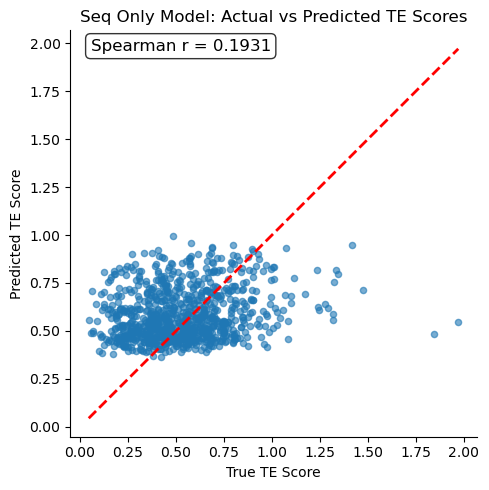

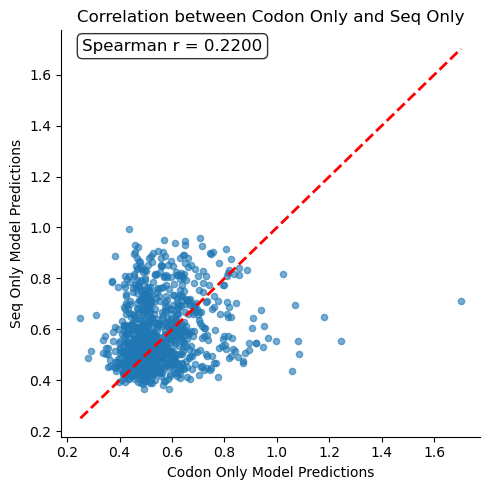

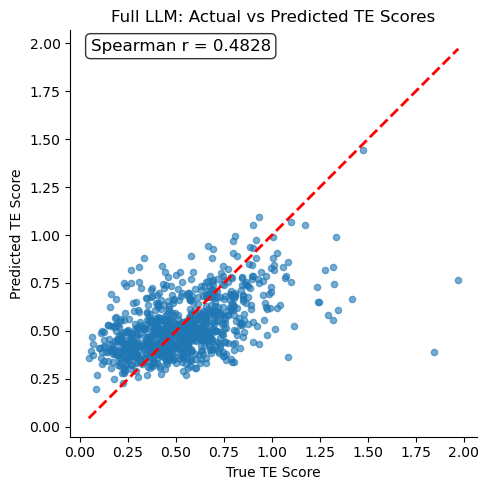

In [15]:
# codon only
from scipy.stats import spearmanr
import pandas as pd
import matplotlib.pyplot as plt

try:
    codon_only = pd.read_csv('dvclive/codonOnlyClassificationMLP/codonOnly_final/test_predictions_vs_true_labels.csv')
except:
    import os
    os.chdir('../..')
    codon_only = pd.read_csv('dvclive/codonOnlyClassificationMLP/codonOnly_final/test_predictions_vs_true_labels.csv')

# Create scatter plot of codon only model predictions vs true labels
plt.figure(figsize=(5, 5))
plt.scatter(codon_only['True Labels'], codon_only['Predictions'], alpha=0.6, s=20)
plt.plot([codon_only['True Labels'].min(), codon_only['True Labels'].max()], 
         [codon_only['True Labels'].min(), codon_only['True Labels'].max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('True TE Score')
plt.ylabel('Predicted TE Score')
plt.title('Codon Only MLP: Actual vs Predicted TE Scores')

# Calculate and add R² score
r_squared = spearmanr(codon_only['True Labels'], codon_only['Predictions'])[0]
plt.text(0.05, 0.95, f'Spearman r = {r_squared:.4f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('figures/codonOnly_model_actual_vs_predicted_TE_scores.svg')
plt.show()


# seq only model
seq_only = pd.read_csv('output/predict_seq_only/predictions_vs_true_labels_seq_only.csv')

# Create scatter plot of seq only model predictions vs true labels
plt.figure(figsize=(5, 5))
plt.scatter(seq_only['True Labels'], seq_only['Predictions'], alpha=0.6, s=20)
plt.plot([seq_only['True Labels'].min(), seq_only['True Labels'].max()], 
         [seq_only['True Labels'].min(), seq_only['True Labels'].max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('True TE Score')
plt.ylabel('Predicted TE Score')
plt.title('Seq Only Model: Actual vs Predicted TE Scores')

# Calculate and add R² score
r_squared = spearmanr(seq_only['True Labels'], seq_only['Predictions'])[0]
plt.text(0.05, 0.95, f'Spearman r = {r_squared:.4f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
ax = plt.gca()
ax.spines['top'].set_visible(False) 
ax.spines['right'].set_visible(False)
plt.savefig('figures/seqOnly_model_actual_vs_predicted_TE_scores.svg')
plt.show()

# correlation between seq only and codon only models
merged = pd.merge(codon_only, seq_only, on='True Labels', suffixes=('_codon', '_seq'))
plt.figure(figsize=(5, 5))
plt.scatter(merged['Predictions_codon'], merged['Predictions_seq'], alpha=0.6, s=20)
plt.plot([merged['Predictions_codon'].min(), merged['Predictions_codon'].max()], 
         [merged['Predictions_codon'].min(), merged['Predictions_codon'].max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Codon Only Model Predictions')
plt.ylabel('Seq Only Model Predictions')
plt.title('Correlation between Codon Only and Seq Only')

# Calculate and add R² score
r_squared = spearmanr(merged['Predictions_codon'], merged['Predictions_seq'])[0]
plt.text(0.05, 0.95, f'Spearman r = {r_squared:.4f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('figures/codon_vs_seq_model_predictions_correlation.svg')
plt.show()

# full LLM model
seq_only = pd.read_csv('output/predict/predictions_vs_true_labels.csv')

# Create scatter plot of seq only model predictions vs true labels
plt.figure(figsize=(5, 5))
plt.scatter(seq_only['True Labels'], seq_only['Predictions'], alpha=0.6, s=20)
plt.plot([seq_only['True Labels'].min(), seq_only['True Labels'].max()], 
         [seq_only['True Labels'].min(), seq_only['True Labels'].max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('True TE Score')
plt.ylabel('Predicted TE Score')
plt.title('Full LLM: Actual vs Predicted TE Scores')

# Calculate and add R² score
r_squared = spearmanr(seq_only['True Labels'], seq_only['Predictions'])[0]
plt.text(0.05, 0.95, f'Spearman r = {r_squared:.4f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
ax = plt.gca()
ax.spines['top'].set_visible(False) 
ax.spines['right'].set_visible(False)
plt.savefig('figures/fullLLM_model_actual_vs_predicted_TE_scores.svg')
plt.show()

# look at the general trends in SHAP scores across the 5'UTR and 3'UTR of all transcripts

In [11]:
import pickle
import os
import numpy as np
from matplotlib import pyplot as plt

try:
    os.chdir('scripts')
    print(os.getcwd())
    from myShap import Explainer
    from myShap.ferret_extras import BaseExplainer, Explanation
    os.chdir('..')
    print(os.getcwd())
    with open("output/importance/dev_shap.pkl", "rb") as f:
        importances_dev = pickle.load(f)
except:
    os.chdir('../../scripts')
    print(os.getcwd())
    from myShap import Explainer
    from myShap.ferret_extras import BaseExplainer, Explanation
    os.chdir('..')
    print(os.getcwd())
    with open("output/importance/dev_shap.pkl", "rb") as f:
        importances_dev = pickle.load(f)

with open("output/importance/train_shap.pkl", "rb") as f:
    importances_train = pickle.load(f)
with open("output/importance/test_shap.pkl", "rb") as f:
    importances_test = pickle.load(f)

importances = {
    "dev": importances_dev,
    "train": importances_train,
    "test": importances_test
}

/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/scripts
/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency


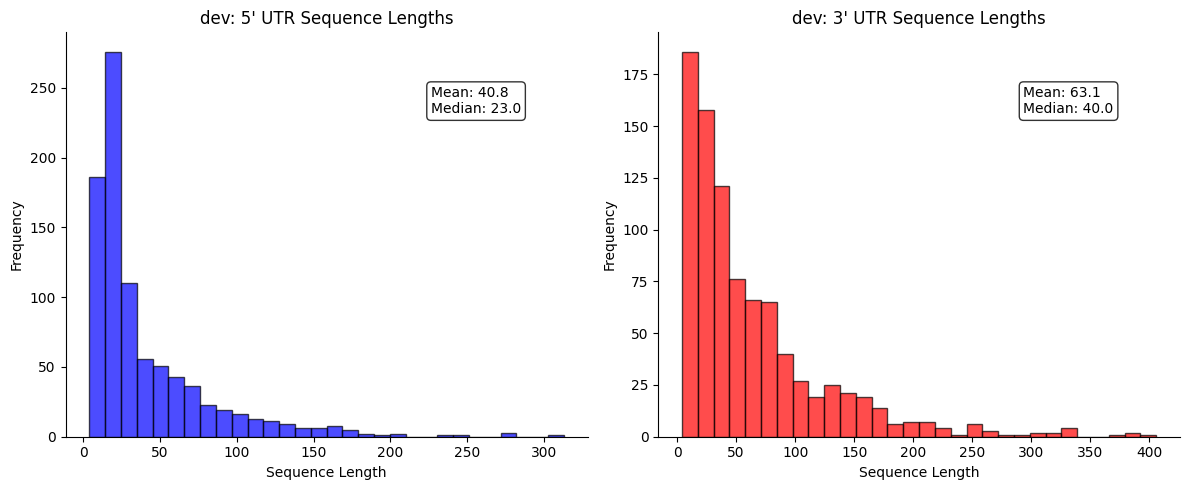

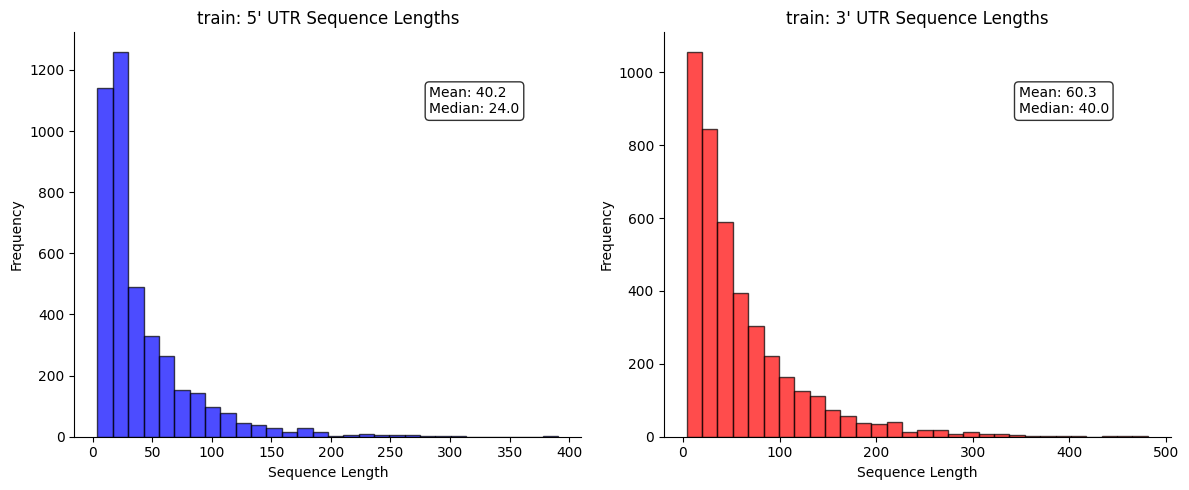

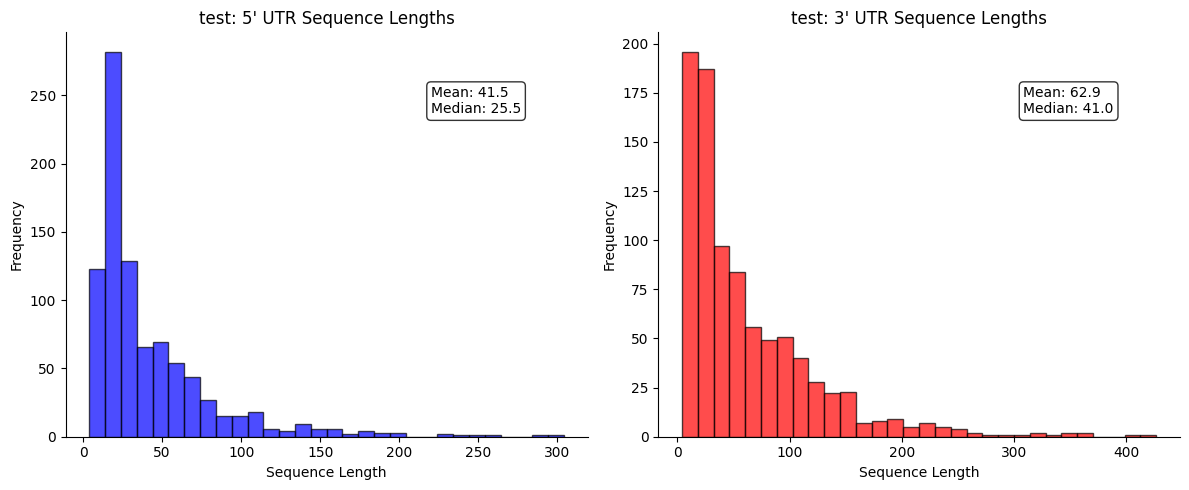

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Example: variable-length sequences
#sequences = [
#    np.array([1, 3, 2, 5, 7]),
#    np.array([2, 4, 6]),
#    np.array([1, 2, 3, 4, 6, 8, 10]),
#    np.array([3, 3.5, 4, 4.5, 5])
#]
seqs5 = {'dev':[], 'train':[], 'test':[]}
seqs3 = {'dev':[], 'train':[], 'test':[]}
for group in ['dev','train','test']:
    for imp in importances[group]:
        tmp5 = imp.scores[1:imp.tokens.index('[SEP]')].flatten()*len(imp.scores) # *len of scores to normalize for length
        tmp3 = imp.scores[imp.tokens.index('[SEP]')+1:-1].flatten()*len(imp.scores)
        if len(tmp5) <= 3 or len(tmp3) <= 3:
            continue
        seqs5[group].append(tmp5)
        seqs3[group].append(tmp3)

    # Calculate lengths of sequences
    lengths_5 = [len(seq) for seq in seqs5[group]]
    lengths_3 = [len(seq) for seq in seqs3[group]]

    # Create histograms
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # 5' UTR length histogram
    ax1.hist(lengths_5, bins=30, alpha=0.7, color='blue', edgecolor='black')
    ax1.set_xlabel('Sequence Length')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f"{group}: 5' UTR Sequence Lengths")
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # Add statistics text
    mean_5 = np.mean(lengths_5)
    median_5 = np.median(lengths_5)
    ax1.text(0.7, 0.8, f'Mean: {mean_5:.1f}\nMedian: {median_5:.1f}', 
             transform=ax1.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 3' UTR length histogram
    ax2.hist(lengths_3, bins=30, alpha=0.7, color='red', edgecolor='black')
    ax2.set_xlabel('Sequence Length')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f"{group}: 3' UTR Sequence Lengths")
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Add statistics text
    mean_3 = np.mean(lengths_3)
    median_3 = np.median(lengths_3)
    ax2.text(0.7, 0.8, f'Mean: {mean_3:.1f}\nMedian: {median_3:.1f}', 
             transform=ax2.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    #plt.savefig('figures/UTR_sequence_length_histograms.svg')
    plt.show()


In [13]:
# Split dev / train / test into separate figures (each with 5' and 3' panels)

target_len = 100  # keep existing interpolation length

def aggregate_pos_neg(sequences, tgt_len):
    pos_list, neg_list = [], []
    x_new = np.linspace(0, 1, tgt_len)
    for seq in sequences:
        if len(seq) < 2:
            continue
        x_old = np.linspace(0, 1, len(seq))
        seq_new = interp1d(x_old, seq, kind="linear")(x_new)
        pos_list.append(np.where(seq_new > 0, seq_new, np.nan))
        neg_list.append(np.where(seq_new < 0, -seq_new, np.nan))  # store magnitudes

    return pos_list, neg_list, x_new



interp = {'dev': {'pos5': None, 'neg5':None, 'pos3': None, 'neg3':None}, 'train': {'pos5': None, 'neg5':None, 'pos3': None, 'neg3':None}, 'test': {'pos5': None, 'neg5':None, 'pos3': None, 'neg3':None}}
for group in ['dev', 'train', 'test']:
    # Prepare (do not mutate originals)
    trunc5 = seqs5[group] #truncate_list(seqs5[group], 100)
    trunc3 = seqs3[group] #truncate_list(seqs3[group], 150)

    # Aggregate
    pos5, neg5, x5 = aggregate_pos_neg(trunc5, target_len)
    pos3, neg3, x3 = aggregate_pos_neg(trunc3, target_len)
    interp[group]['pos5'] = pos5
    interp[group]['neg5'] = neg5
    interp[group]['pos3'] = pos3
    interp[group]['neg3'] = neg3






In [14]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import pandas as pd
import scipy.stats as stats

groups = ['train', 'dev', 'test']

def mixed_pos_neg(interp, pos_key, neg_key, alpha=0.05):
    records = []
    for g in groups:
        if pos_key not in interp[g] or neg_key not in interp[g]:
            continue
        for seq in interp[g][pos_key]:
            for pos, val in enumerate(seq):
                records.append({'dataset': g, 'position': pos, 'sign': 'pos', 'value': val})
        for seq in interp[g][neg_key]:
            for pos, val in enumerate(seq):
                records.append({'dataset': g, 'position': pos, 'sign': 'neg', 'value': val})

    df = pd.DataFrame.from_records(records).dropna(subset=['value'])
    if df.empty:
        return pd.DataFrame()

    results = []
    for pos in sorted(df.position.unique()):
        df_pos = df[df.position == pos]
        if df_pos.sign.nunique() < 2:
            results.append({"position": pos})
            continue
        try:
            fit = smf.ols("value ~ sign + dataset", df_pos).fit()
        except Exception:
            results.append({"position": pos})
            continue

        # Parameters
        b0 = fit.params.get("Intercept", np.nan)          # mean_neg
        b1_name = [p for p in fit.params.index if p.startswith("sign")][0]
        b1 = fit.params[b1_name]                          # diff = mean_pos - mean_neg
        V = fit.cov_params()
        V00 = V.loc["Intercept", "Intercept"]
        V11 = V.loc[b1_name, b1_name]
        V01 = V.loc["Intercept", b1_name]

        mean_neg = b0
        mean_pos = b0 + b1
        se_diff = np.sqrt(V11)

        # Raw p-value for diff
        pval = fit.pvalues[b1_name]

        # Standard 95% CIs (optional)
        tcrit_std = stats.t.ppf(1 - 0.05/2, fit.df_resid)
        se_neg = np.sqrt(V00)
        se_pos = np.sqrt(V00 + V11 + 2*V01)
        ci_neg = (mean_neg - tcrit_std*se_neg, mean_neg + tcrit_std*se_neg)
        ci_pos = (mean_pos - tcrit_std*se_pos, mean_pos + tcrit_std*se_pos)

        # Comparison intervals (non-overlap ⇔ p < alpha)
        tcrit = stats.t.ppf(1 - alpha/2, fit.df_resid)
        h = tcrit * se_diff / 2.0
        comp_neg = (mean_neg - h, mean_neg + h)
        comp_pos = (mean_pos - h, mean_pos + h)

        results.append({
            "position": pos,
            "mean_neg": mean_neg,
            "mean_pos": mean_pos,
            "p_raw": pval,
            "ci_neg_lower": ci_neg[0], "ci_neg_upper": ci_neg[1],
            "ci_pos_lower": ci_pos[0], "ci_pos_upper": ci_pos[1],
            "comp_neg_lower": comp_neg[0], "comp_neg_upper": comp_neg[1],
            "comp_pos_lower": comp_pos[0], "comp_pos_upper": comp_pos[1]
        })

    res_df = pd.DataFrame(results)
    if not res_df.empty and res_df.p_raw.notna().any():
        res_df["p_adj"] = multipletests(res_df.p_raw.fillna(1.0), method="fdr_bh")[1]
    else:
        res_df["p_adj"] = np.nan
    return res_df

res_5 = mixed_pos_neg(interp, 'pos5', 'neg5')
res_3 = mixed_pos_neg(interp, 'pos3', 'neg3')


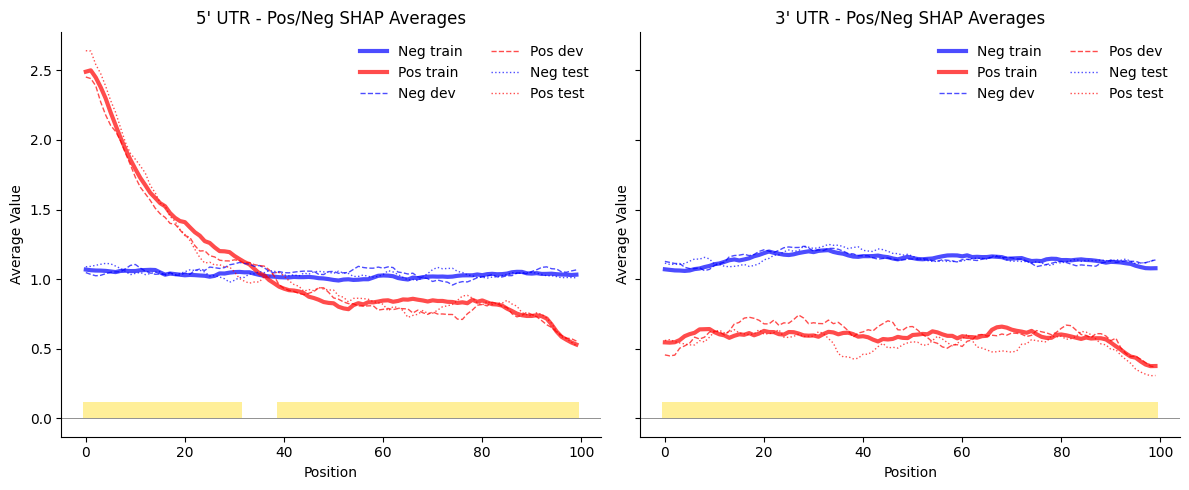

In [15]:
# Plot per-dataset curves (averages instead of proportions)
linestyles = {'dev': '--', 'train': '-', 'test': ':'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for i, (pos_key, neg_key) in enumerate([('pos5','neg5'), ('pos3','neg3')]):
    ax = axes[i]
    label = "5' UTR" if pos_key == 'pos5' else "3' UTR"
    
    # Collect records from all groups
    records = []
    for g in groups:
        if pos_key not in interp[g] or neg_key not in interp[g]:
            continue
        for seq in interp[g][pos_key]:
            for pos, val in enumerate(seq):
                records.append({'dataset': g, 'position': pos, 'sign': 'pos', 'value': val})
        for seq in interp[g][neg_key]:
            for pos, val in enumerate(seq):
                records.append({'dataset': g, 'position': pos, 'sign': 'neg', 'value': val})

    df = pd.DataFrame.from_records(records).dropna(subset=['value'])
    if df.empty:
        continue

    # # Compute overall means and stds across all datasets
    # grouped = df.groupby(['position','sign'])['value']
    # means_g = grouped.mean().unstack('sign').fillna(0)
    # stds_g = grouped.std().unstack('sign').fillna(0)
    # # Ensure both columns exist
    # for s in ['pos','neg']:
    #     if s not in means_g.columns:
    #         means_g[s] = 0
    #         stds_g[s] = 0

    ## Plot combined averages (thicker lines)
    #ax.plot(means_g.index, means_g['neg'], color='blue', linestyle='-', linewidth=3, label='Neg combined mean')
    #ax.plot(means_g.index, means_g['pos'], color='red', linestyle='-', linewidth=3, label='Pos combined mean')

    # Plot individual dataset averages (thinner lines)
    for g in groups:
        sub = df[df.dataset == g]
        if sub.empty:
            continue
        means_ds = sub.groupby(['position','sign'])['value'].mean().unstack('sign').fillna(0)
        for s in ['pos','neg']:
            if s not in means_ds.columns:
                means_ds[s] = 0
        ax.plot(means_ds.index, means_ds['neg'], color='blue', linestyle=linestyles[g], linewidth=(3 if g=='train' else 1), alpha=0.7, label=f'Neg {g}')
        ax.plot(means_ds.index, means_ds['pos'], color='red', linestyle=linestyles[g], linewidth=(3 if g=='train' else 1), alpha=0.7, label=f'Pos {g}')

    ax.set_xlabel('Position')
    ax.set_ylabel('Average Value')
    ax.set_title(f"{label} - Pos/Neg SHAP Averages")
    ax.axhline(0, color='black', lw=0.5, alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, ncol=2)

    # Mark significant where intervals do not overlap
    # Highlight contiguous significant regions (p_adj < 0.05) with boxes at y=0
    res_df = res_5 if pos_key == 'pos5' else res_3
    if 'p_adj' in res_df.columns and res_df['p_adj'].notna().any():
        sig_positions = sorted(res_df.loc[res_df['p_adj'] < 0.05, 'position'].unique())
        if sig_positions:
            # Build contiguous ranges
            ranges = []
            for p in sig_positions:
                if not ranges or p != ranges[-1][1] + 1:
                    ranges.append([p, p])
                else:
                    ranges[-1][1] = p
            # Determine a small box height
            ymin, ymax = ax.get_ylim()
            height = (ymax - ymin) * 0.04  # 4% of y-range
            import matplotlib.patches as patches
            added_label = False
            for start, end in ranges:
                # Expand half step to make the box span the positions nicely
                x0 = start - 0.5
                width = (end - start + 1)
                rect = patches.Rectangle(
                    (x0, 0), width, height,
                    facecolor='gold', edgecolor='none', alpha=0.4,
                    zorder=0.1,
                    label='p_adj<0.05' if not added_label else None
                )
                ax.add_patch(rect)
                added_label = True

plt.tight_layout()
plt.savefig(f'figures/SHAP_averages_combined_with_individual.svg', bbox_inches='tight')
plt.show()


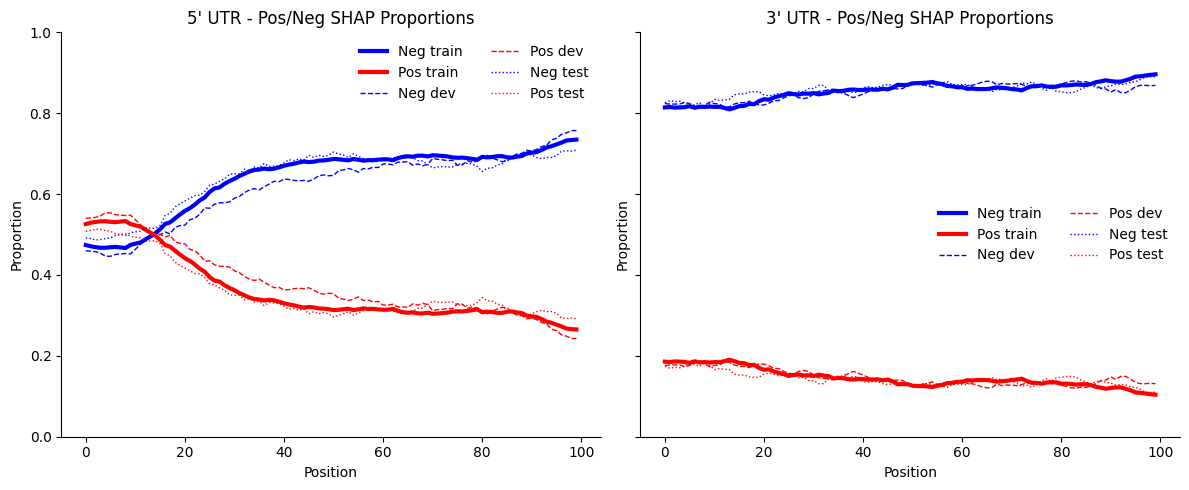

In [16]:
import numpy as np

import matplotlib.pyplot as plt

# Assuming interp and groups are defined from previous cells
# interp = {'dev': {'pos5': ..., 'neg5': ..., 'pos3': ..., 'neg3': ...}, ...}
# groups = ['dev', 'train', 'test']

linestyles = {'dev': '--', 'train': '-', 'test': ':'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, (pos_key, neg_key) in enumerate([('pos5','neg5'), ('pos3','neg3')]):
    ax = axes[i]
    label = "5' UTR" if pos_key == 'pos5' else "3' UTR"
    
    # Collect records
    records = []
    for g in groups:
        if pos_key not in interp[g] or neg_key not in interp[g]:
            continue
        for seq in interp[g][pos_key]:
            for pos, val in enumerate(seq):
                records.append({'dataset': g, 'position': pos, 'sign': 'pos', 'value': val})
        for seq in interp[g][neg_key]:
            for pos, val in enumerate(seq):
                records.append({'dataset': g, 'position': pos, 'sign': 'neg', 'value': val})

    df = pd.DataFrame.from_records(records).dropna(subset=['value'])
    if df.empty:
        continue

    for g in groups:
        sub = df[df.dataset == g]
        if sub.empty:
            continue
        counts_g = sub.groupby(['position','sign']).size().unstack('sign').fillna(0)
        # Ensure both columns exist
        for s in ['pos','neg']:
            if s not in counts_g.columns:
                counts_g[s] = 0
        props = counts_g.div(counts_g.sum(axis=1), axis=0).fillna(0)
        ax.plot(props.index, props['neg'], color='blue', linestyle=linestyles[g], label=f'Neg {g}', linewidth=(3 if g=='train' else 1))
        ax.plot(props.index, props['pos'], color='red', linestyle=linestyles[g], label=f'Pos {g}' , linewidth=(3 if g=='train' else 1))

    ax.set_xlabel('Position')
    ax.set_ylabel('Proportion')
    ax.set_title(f"{label} - Pos/Neg SHAP Proportions")
    ax.axhline(0, color='black', lw=0.5, alpha=0.6)
    ax.set_ylim(0,1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, ncol=2)

plt.tight_layout()
plt.savefig(f'figures/SHAP_trends_combined_panels.svg', bbox_inches='tight')
plt.show()


# Best Hyperparameters via Ray Tune

In [18]:
import os
import json
import pandas as pd

configs = []
json_path = '/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/ray_results/best_ray_tune_config.json'
with open(json_path, 'r') as f:
    data = json.load(f)
data['analysis'] = 'full_LLM'
configs.append(data)

path = '/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/ray_ablations'
subdirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
for subdir in subdirs:
    json_path = os.path.join(path, subdir, 'best_ray_tune_config.json')
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            data = json.load(f)
        data['analysis'] = subdir
        configs.append(data)

path = '/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/codonOnlyClassificationMLP'
subdirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
print(subdirs)
for subdir in subdirs:
    json_path = os.path.join(path, subdir, 'best_hyperparameters.json')
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            tmp = json.load(f)
            data = {'analysis': subdir, 'classifier_lr':tmp['learning_rate'], 'classifier_dropout':tmp['dropout_percent'], 'classifier_weight_decay':tmp['weight_decay']}
        configs.append(data)


df_configs = pd.DataFrame(configs)
df_configs.set_index('analysis', inplace=True)
os.makedirs('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/figures/tables', exist_ok=True)
df_configs.to_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/figures/tables/ray_ablations_summary.csv')
df_configs

['extraFeaturesAndMotifCounts', 'codonOnly', 'allExtraFeatures']


,bert_lr,classifier_lr,bert_weight_decay,classifier_weight_decay,bert_hidden_dropout,bert_atten_dropout,classifier_dropout,projector_dropout
analysis,,,,,,,,
full_LLM,0.000087,0.000993,0.059460,0.069538,0.219957,0.433747,0.422876,0.105337
no_lengths,0.000040,0.000995,0.071219,0.065122,0.306052,0.237575,0.237078,0.392110
only_codons,0.000030,0.000388,0.057816,0.088471,0.378872,0.194734,0.177516,0.400968
seq_only,0.000072,0.000024,0.028422,0.005268,0.128379,0.394952,0.301629,0.679509
no_mfe,0.000008,0.000977,0.090552,0.067660,0.270363,0.274939,0.138279,0.314546
no_codons,0.000055,0.000010,0.099503,0.071025,0.123644,0.212894,0.471197,0.682773
no_gc_content,0.000005,0.000983,0.001983,0.055213,0.436288,0.325902,0.196545,0.558915
extraFeaturesAndMotifCounts,NaN,0.003849,NaN,0.058531,NaN,NaN,0.740683,NaN
codonOnly,NaN,0.003289,NaN,0.019210,NaN,NaN,0.778411,NaN


# show TE distributions

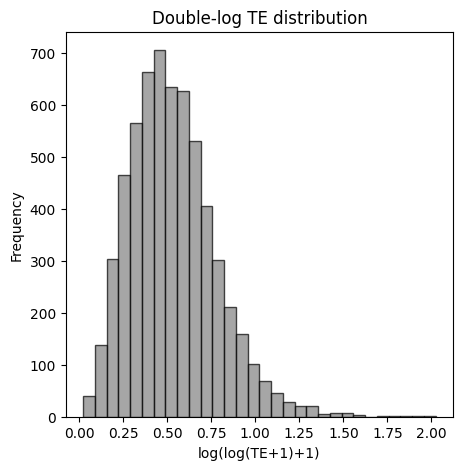

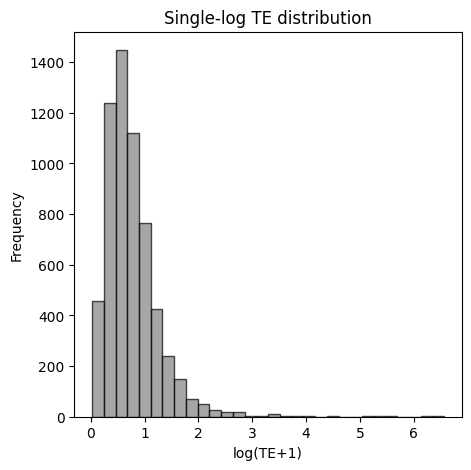

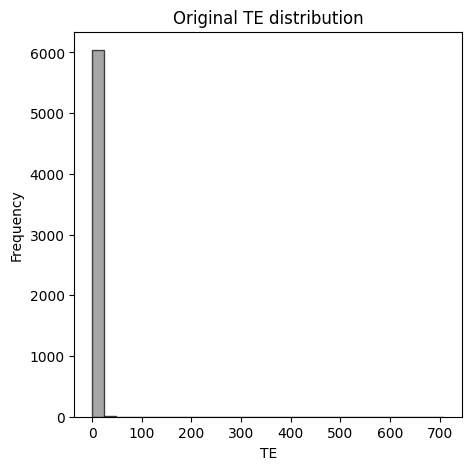

In [19]:
from Bio import SeqIO

dev = SeqIO.parse('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/data/decay/dev.fasta', 'fasta')
train = SeqIO.parse('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/data/decay/train.fasta', 'fasta')
test = SeqIO.parse('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/data/decay/test.fasta', 'fasta')

TE = []
for records in [dev, train, test]:
    for r in records:
        TE.append(float(r.id))

TE
import matplotlib.pyplot as plt
import numpy as np 

plt.figure(figsize=(5,5))
plt.hist(TE, bins=30, color='gray', edgecolor='black', alpha=0.7)
plt.title("Double-log TE distribution")
plt.xlabel("log(log(TE+1)+1)")
plt.ylabel("Frequency")
plt.savefig('figures/TE_distribution_double_log.svg', bbox_inches='tight')
plt.show()
plt.figure(figsize=(5,5))
plt.hist(np.exp(TE)-1, bins=30, color='gray', edgecolor='black', alpha=0.7)
plt.title("Single-log TE distribution")
plt.xlabel("log(TE+1)")
plt.ylabel("Frequency")
plt.savefig('figures/TE_distribution_single_log.svg', bbox_inches='tight')
plt.show()
plt.figure(figsize=(5,5))
plt.hist(np.exp(np.exp(TE)-1)-1, bins=30, color='gray', edgecolor='black', alpha=0.7)
plt.title("Original TE distribution")
plt.xlabel("TE")
plt.ylabel("Frequency")
plt.savefig('figures/TE_distribution_original.svg', bbox_inches='tight')
plt.show()

# Are RBP hits actually expressed

In [34]:
import pandas as pd
key = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/data/GeneID_to_FlybaseID.txt', sep='\t', index_col=2,header=None)
key.index = [str(x).upper() for x in key.index]
key = {k:v for k,v in key[1].to_dict().items()}
key.update({'CG33714':'FBgn0064117', "CG2950":'FBgn0031637', "CG7804":'FBgn0036496','BRU-3':'FBgn0264001','CG17838': 'FBgn0038826', 'CG5213':'FBgn0038345', 'A2BP1':'FBgn0052062', 'ARET':'FBgn0000114', 'EIF-2ALPHA':'FBgn0290109'})
keyInv = {v:k for k,v in key.items()}
genesOfInterest = set()
for k,geneList in myInterestRBPs.items():
    for gene in geneList:
        genesOfInterest.add(gene)
#genesOfInterest = ['CG17838', 'CG2931', 'FMR1', 'MOD', 'REF2','ARET', 'PAPI', 'RNP4F','BRU-3', 'HOW', 'MUB', 'RBP9', 'ROX8', 'SM', 'CG14718','CNOT4', 'RBP1', 'RBP1-LIKE']
geneExpression = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/data/translationEfficiency/2h_TE.csv', index_col=0)
geneExpression = geneExpression.loc[[key.get(g) for g in genesOfInterest if key.get(g) in geneExpression.index]]
geneExpression

#geneExpression = geneExpression.loc[[fbgn for fbgn in key2.values() if fbgn in geneExpression.index]]
geneExpression['gene'] = [keyInv[fbgn] for fbgn in geneExpression.index]
geneExpression.set_index('gene', inplace=True)
#print(geneExpression.iloc[:,6:9])
tmp = pd.DataFrame({'riboLevel': pd.Series(geneExpression.iloc[:,0:3].mean(axis=1)),'rnaLevel': pd.Series(geneExpression.iloc[:,6:9].mean(axis=1))})
tmp.sort_values('rnaLevel', inplace=True, ascending=False)
tmp

,riboLevel,rnaLevel
gene,,
PABP,2191.453146,5131.004766
MOD,10104.421059,3423.830205
ROX8,669.896353,2331.872738
HRB27C,2858.673474,2275.770445
HRB98DE,3550.494948,2217.284579
ARET,426.372711,2022.284182
SF2,2001.237150,1728.260893
LARK,865.921929,1384.955867
U2AF50,1888.905553,1268.066409


# Variance / correlation between TE replicates

In [9]:
import pandas as pd
import numpy as np
TE = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/data/translationEfficiency/2h_TE.csv', index_col=0)
TE = TE[(TE.iloc[:,[3,4,5,9,10,11]] > 0).sum(1) == 6]
TE

,RPFs.DC7_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFs.DC8_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFs.DC9_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFsRawCounts.DC7_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFsRawCounts.DC8_184t_bw_star_Aligned.sortedByCoord.out.bam,RPFsRawCounts.DC9_184t_bw_star_Aligned.sortedByCoord.out.bam,mRNA.DC10_184t_star_Aligned.sortedByCoord.out.bam,mRNA.DC11_184t_star_Aligned.sortedByCoord.out.bam,mRNA.DC12_184t_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC10_184t_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC11_184t_star_Aligned.sortedByCoord.out.bam,mRNARawCounts.DC12_184t_star_Aligned.sortedByCoord.out.bam,TE.DC7_184t_bw_star_Aligned.sortedByCoord.out.bam,TE.DC8_184t_bw_star_Aligned.sortedByCoord.out.bam,TE.DC9_184t_bw_star_Aligned.sortedByCoord.out.bam
FBgn0000008,56.636787,43.464537,34.899195,21,15,9,149.205138,144.562690,135.885761,557,525,493,0.383720,0.305467,0.262257
FBgn0000014,21.327739,22.914443,7.666169,8,8,2,8.738121,12.248557,10.081015,33,45,37,2.292818,1.805060,0.782074
FBgn0000015,1.238360,3.991468,1.780494,1,3,1,0.614987,2.781552,3.796784,5,22,30,1.385992,1.319952,0.579658
FBgn0000017,339.437391,302.276828,383.224144,298,247,234,331.934807,311.321699,309.534792,2934,2677,2659,1.022535,0.971040,1.237298
FBgn0000018,105.807993,157.402678,93.617858,13,18,8,118.025881,146.253207,113.957630,146,176,137,0.897351,1.075716,0.823067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FBgn0288686,52.189646,93.453933,108.387395,9,15,13,30.525795,7.696669,14.223314,53,13,24,1.687179,10.860933,7.185518
FBgn0288690,43.610245,59.633235,51.301722,11,14,9,167.353209,138.837751,120.742406,425,343,298,0.264980,0.433597,0.429610
FBgn0288833,1106.503205,1515.166441,2121.216525,51,65,68,1305.883377,1134.148872,1310.441681,606,512,591,0.847438,1.335654,1.618232
FBgn0288834,363.900388,847.108631,457.808826,24,52,21,1566.224041,1486.141338,1419.431595,1040,960,916,0.232832,0.570295,0.323007


In [ ]:
from scipy.stats import spearmanr

cor1_2 = spearmanr(TE['TE.DC7_184t_bw_star_Aligned.sortedByCoord.out.bam'], TE['TE.DC8_184t_bw_star_Aligned.sortedByCoord.out.bam'])[0]
cor1_3 = spearmanr(TE['TE.DC7_184t_bw_star_Aligned.sortedByCoord.out.bam'], TE['TE.DC9_184t_bw_star_Aligned.sortedByCoord.out.bam'])[0]
cor2_3 = spearmanr(TE['TE.DC8_184t_bw_star_Aligned.sortedByCoord.out.bam'], TE['TE.DC9_184t_bw_star_Aligned.sortedByCoord.out.bam'])[0]

print(cor1_2)
print(cor1_3)
print(cor2_3)

0.8191068862234905
0.7816790076426574
0.8400049537525105


In [15]:
myTE = (TE.iloc[:,[1,2,3]].mean(1)+1)/(TE.iloc[:,[6,7,8]].mean(1)+1)

corTE = spearmanr(myTE, TE['TE.DC7_184t_bw_star_Aligned.sortedByCoord.out.bam'])[0]
print(corTE)
corTE = spearmanr(myTE, TE['TE.DC8_184t_bw_star_Aligned.sortedByCoord.out.bam'])[0]
print(corTE)
corTE = spearmanr(myTE, TE['TE.DC9_184t_bw_star_Aligned.sortedByCoord.out.bam'])[0]
print(corTE)


0.8659240383588067
0.9480407840460401
0.9462787046316768


In [16]:
altTE = TE.iloc[:,[12,13,14]].mean(1)
corAltTE = spearmanr(altTE, TE['TE.DC7_184t_bw_star_Aligned.sortedByCoord.out.bam'])[0]
print(corAltTE)
corAltTE = spearmanr(altTE, TE['TE.DC8_184t_bw_star_Aligned.sortedByCoord.out.bam'])[0]
print(corAltTE)
corAltTE = spearmanr(altTE, TE['TE.DC9_184t_bw_star_Aligned.sortedByCoord.out.bam'])[0]
print(corAltTE)

0.9140878212367176
0.9433070264252134
0.9356767571288531


# train, val, test splits

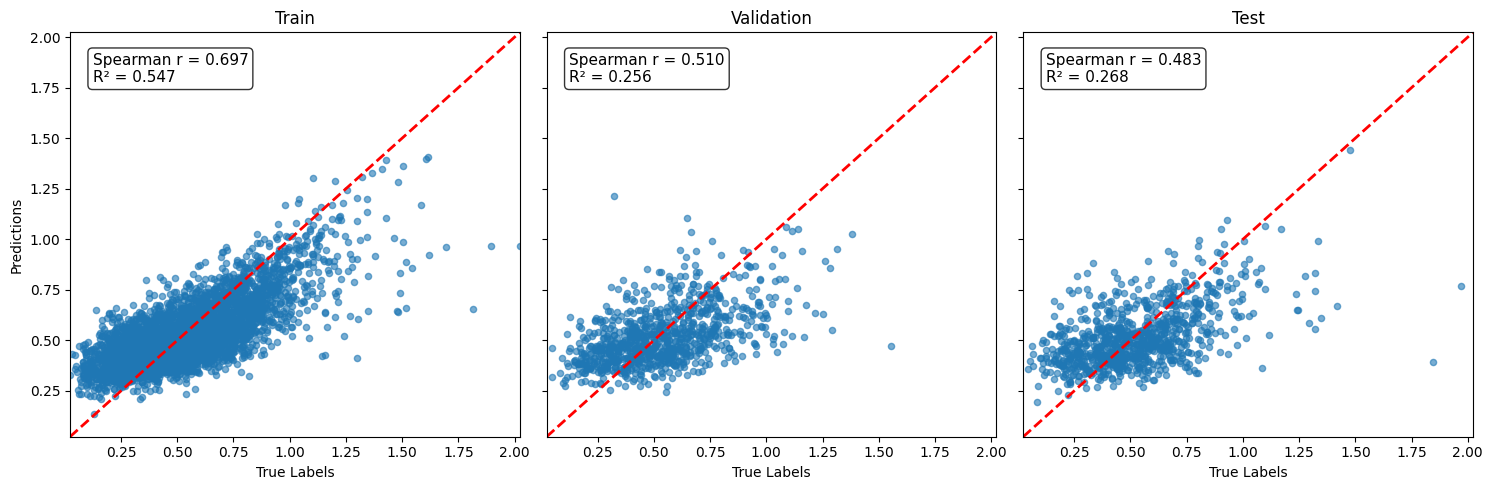

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

train = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/predict/train_predictions_vs_true_labels.csv')
val = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/predict/dev_predictions_vs_true_labels.csv')
test = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/predict/test_predictions_vs_true_labels.csv')

# Spearman correlations
rho_train = train['True Labels'].corr(train['Predictions'], method='spearman')
rho_val = val['True Labels'].corr(val['Predictions'], method='spearman')
rho_test = test['True Labels'].corr(test['Predictions'], method='spearman')

# R² scores
r2_train = r2_score(train['True Labels'], train['Predictions'])
r2_val = r2_score(val['True Labels'], val['Predictions'])
r2_test = r2_score(test['True Labels'], test['Predictions'])

# Combine all data to set consistent axis limits
all_true = pd.concat([train['True Labels'], val['True Labels'], test['True Labels']])
all_pred = pd.concat([train['Predictions'], val['Predictions'], test['Predictions']])
x_min = min(all_true.min(), all_pred.min())
x_max = max(all_true.max(), all_pred.max())
y_min, y_max = x_min, x_max

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

# Plot train
axes[0].scatter(train['True Labels'], train['Predictions'], alpha=0.6, s=20)
axes[0].plot([x_min, x_max], [x_min, x_max], 'r--', lw=2)
axes[0].set_xlabel('True Labels')
axes[0].set_ylabel('Predictions')
axes[0].set_title('Train')
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)
axes[0].text(0.05, 0.95, f"Spearman r = {rho_train:.3f}\nR² = {r2_train:.3f}", transform=axes[0].transAxes,
             va='top', ha='left', fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot val
axes[1].scatter(val['True Labels'], val['Predictions'], alpha=0.6, s=20)
axes[1].plot([x_min, x_max], [x_min, x_max], 'r--', lw=2)
axes[1].set_xlabel('True Labels')
axes[1].set_title('Validation')
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)
axes[1].text(0.05, 0.95, f"Spearman r = {rho_val:.3f}\nR² = {r2_val:.3f}", transform=axes[1].transAxes,
             va='top', ha='left', fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot test
axes[2].scatter(test['True Labels'], test['Predictions'], alpha=0.6, s=20)
axes[2].plot([x_min, x_max], [x_min, x_max], 'r--', lw=2)
axes[2].set_xlabel('True Labels')
axes[2].set_title('Test')
axes[2].set_xlim(x_min, x_max)
axes[2].set_ylim(y_min, y_max)
axes[2].text(0.05, 0.95, f"Spearman r = {rho_test:.3f}\nR² = {r2_test:.3f}", transform=axes[2].transAxes,
             va='top', ha='left', fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('figures/predictions_vs_true_labels_scatter_plots.svg', bbox_inches='tight')
plt.show()


# Motif Families

Parsed 67 motifs — correlation matrix shape: (67, 67)


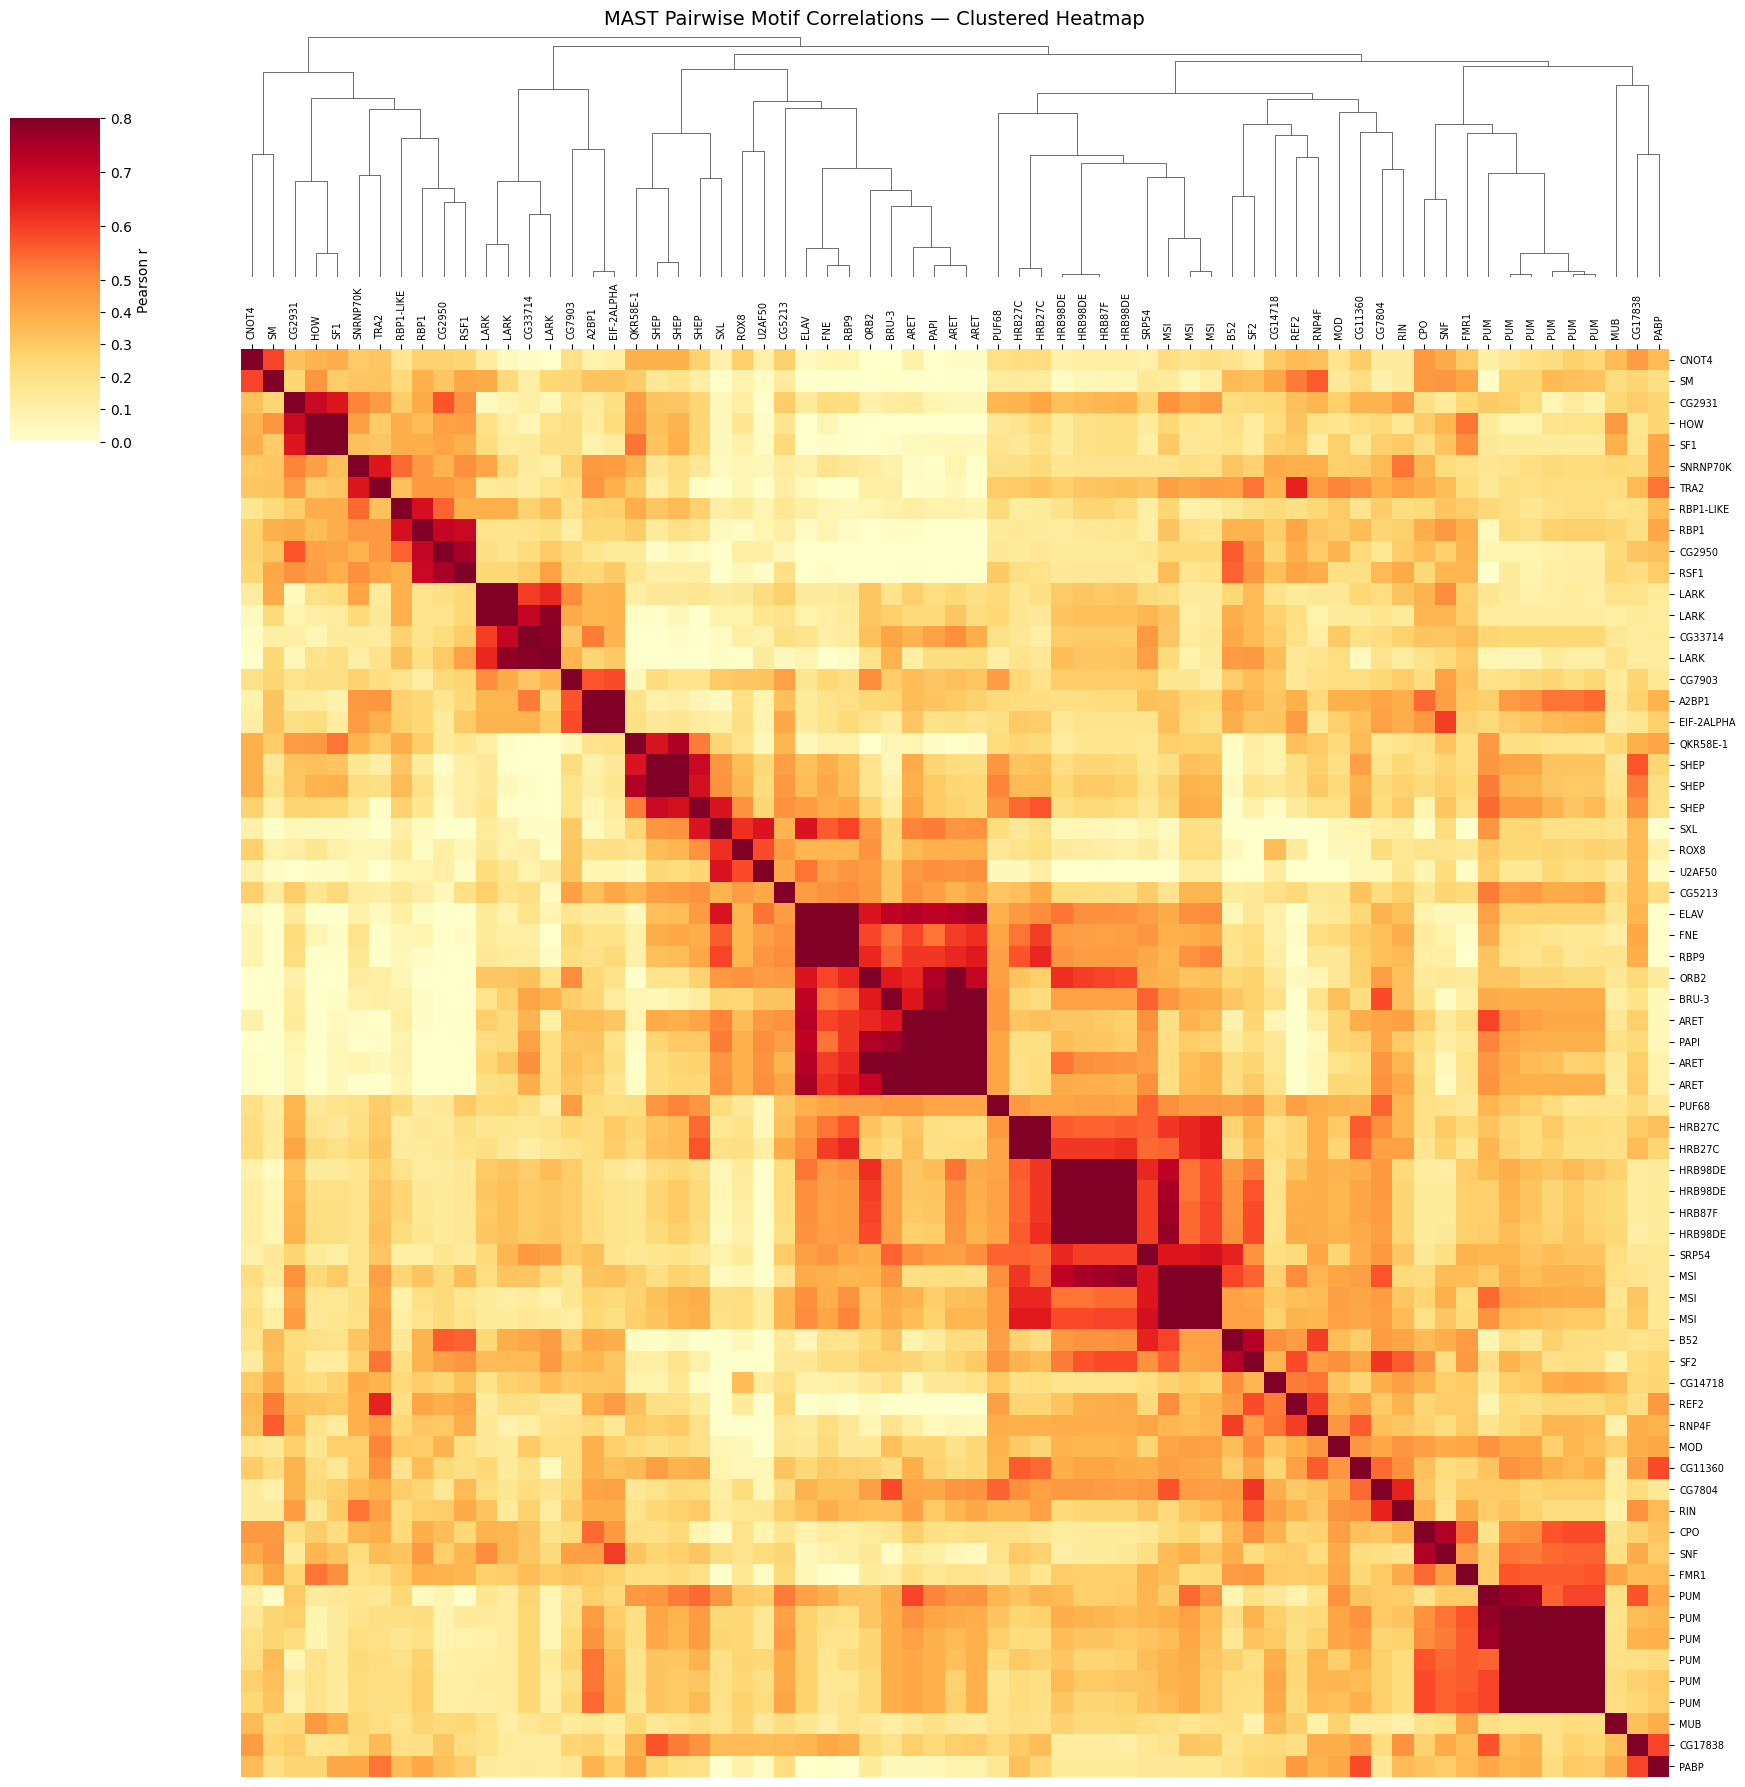

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage
from pathlib import Path

# Path to the MAST output file (relative to this notebook)
mast_file = Path("../../output/mast_out/dev/mast.txt")

# ── 1. Parse motif labels ─────────────────────────────────────────────
motif_labels = {}
in_motif_table = False
with open(mast_file) as fh:
    for line in fh:
        stripped = line.strip()
        if re.search(r"MOTIF\s+ID.*ALT\s+ID", stripped):
            in_motif_table = True
            continue
        if in_motif_table:
            if re.match(r"^-", stripped):
                continue
            m = re.match(r"^(\d+)\s+\S+\s+(\S+)\s+\d+\s+\S+", stripped)
            if m:
                motif_labels[int(m.group(1))] = m.group(2)
            elif "PAIRWISE" in stripped or stripped == "":
                in_motif_table = False
                break

# ── 2. Parse pairwise correlation matrix ──────────────────────────────
n = max(motif_labels.keys())
corr = np.eye(n)

in_corr = False
with open(mast_file) as fh:
    for line in fh:
        stripped = line.strip()
        if stripped.startswith("PAIRWISE MOTIF CORRELATIONS:"):
            in_corr = True
            continue
        if in_corr:
            if re.match(r"^MOTIF", stripped) or re.match(r"^-{3}", stripped):
                continue
            tokens = stripped.split()
            if not tokens:
                break
            try:
                row = int(tokens[0])
            except ValueError:
                break
            for col_idx, val in enumerate(tokens[1:], start=1):
                corr[row - 1, col_idx - 1] = float(val)
                corr[col_idx - 1, row - 1] = float(val)

# ── 3. Build DataFrame with readable labels ────────────────────────────
labels = [f"{motif_labels[i]}" for i in range(1, n + 1)]
df_corr = pd.DataFrame(corr, index=labels, columns=labels)
print(f"Parsed {n} motifs — correlation matrix shape: {df_corr.shape}")
df_corr.iloc[:5, :5]

from matplotlib.colors import TwoSlopeNorm

# Distance matrix for hierarchical clustering
dist = 1.0 - corr
np.fill_diagonal(dist, 0.0)
dist = np.clip(dist, 0, None)          # guard tiny negative floats
condensed = squareform(dist, checks=False)

row_linkage = linkage(condensed, method="average")
col_linkage = linkage(condensed, method="average")

# Centre the colourmap at 0.6 (MAST significance threshold).
# Values 0–0.6 occupy the yellow half; 0.6–1.0 the orange→red half,
# making the threshold the obvious visual inflection point.
norm = TwoSlopeNorm(vmin=0.0, vcenter= 0.5, vmax=0.8)

g = sns.clustermap(
    df_corr,
    cmap="YlOrRd",
    norm=norm,
    row_linkage=row_linkage,
    col_linkage=col_linkage,
    figsize=(18, 18),
    linewidths=0,
    xticklabels=True,
    yticklabels=True,
    annot=False,
    cbar_kws={"label": "Pearson r"},
    dendrogram_ratio=0.15,
)

# Remove the left (row) dendrogram
g.ax_row_dendrogram.set_visible(False)

# Move x-axis labels to the top so the column dendrogram points to them
g.ax_heatmap.xaxis.tick_top()
g.ax_heatmap.xaxis.set_ticks_position("top")
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=7
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=7
)

# Add a gap between the column dendrogram and the heatmap so that the
# rotated x-axis labels have room to breathe.  The dendrogram axes and
# heatmap axes are adjacent with no spacing by default; shifting the
# dendrogram upward carves out the required space without changing its size.
dend_pos = g.ax_col_dendrogram.get_position()
g.ax_col_dendrogram.set_position([
    dend_pos.x0,
    dend_pos.y0 + 0.04,   # push dendrogram up ~5 % of figure height
    dend_pos.width,
    dend_pos.height,
])
# Small pad between tick marks and label anchor
g.ax_heatmap.tick_params(axis="x", pad=4)

g.fig.suptitle(
    "MAST Pairwise Motif Correlations — Clustered Heatmap",
    y=1.04,
    fontsize=14,
)
plt.show()
